# 04 Chronos-2, Zero-Shot-Prognose mit einem Foundation Model

**AI for Business Prognosis, Capstone Projekt Multi Country BIP Prognose**

Dieses Notebook prognostiziert das reale BIP-Wachstum von 116 Ländern über einen
Horizont von fünf Jahren mit **Chronos-2**, einem vortrainierten Zeitreihen-Foundation-Model
von Amazon Science. Es liefert den Zero-Shot-Beitrag zum Methodenvergleich des Teams:
Anders als SARIMAX (Notebook 02) und der Temporal Fusion Transformer (Notebook 03) wird
Chronos-2 **nicht** auf unseren Daten trainiert. Das Modell wird geladen und prognostiziert
sofort, ausschließlich aus dem Kontext der jeweiligen Länderreihe und ihrer Kovariaten.

| Abschnitt | Inhalt | CRISP-DM-Phase |
|---|---|---|
| 0 | Setup | – |
| 1 | Business und Data Understanding | Business Understanding, Data Understanding |
| 2 | Methodik, Chronos-2 | Modeling |
| 3 | Data Preparation für Chronos-2 | Data Preparation |
| 4 | Zero-Shot-Backtest über alle Origins | Modeling |
| 5 | Ergebnisse und Diagnostik | Evaluation |
| 6 | Aggregierte Weltreihe | Modeling, Evaluation |
| 7 | Diskussion, Grenzen und Ausblick | Evaluation |
| 8 | Schnittstelle zu Notebook 05 | Deployment |

Der Schwerpunkt liegt dabei auf der **aggregierten Weltreihe** (Abschnitt 6). Für einzelne
Volkswirtschaften gilt eine Fünfjahresprognose des BIP-Wachstums in der Literatur als kaum
belastbar, weil länderspezifische Schocks dominieren (*An, Z., Jalles, J. T., & Loungani, P. (2018).*
*How well do economists forecast recessions?*). Beim Aufsummieren zur Welt mitteln sich diese Schocks weitgehend
heraus, und der gemeinsame Konjunkturzyklus bleibt übrig. Die Länderprognosen aus den
Abschnitten 4 und 5 sind deshalb zugleich Ergebnis für den Methodenvergleich **und** Vorstufe
für die Bottom-up-Weltprognose.

Das Notebook folgt der in `01_Datenbeschaffung_Aufbereitung.ipynb` festgelegten Schnittstelle.
Es lädt `data/processed/gdp_panel.csv` über `src.data_utils.load_panel()` und speichert seine
Prognosen über `src.evaluation.save_predictions(df, "chronos2")` im Standardschema
`src.config.RESULTS_COLUMNS` nach `data/results/preds_chronos2.csv`. Der finale,
modellübergreifende Vergleich folgt in `05_Vergleich.ipynb`.

## 0 Setup

In [34]:
# --- Imports ----------------------------------------
import sys
import time
import warnings
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError

# Setzt die Projektwurzel CapstoneProjekt_BPI in den Suchpfad, damit src importierbar ist.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src import config, data_utils, evaluation, plotting

# Chronos-2 hier importieren. Fehlt das Paket, bricht das Notebook nicht hart ab,
# sondern gibt beim Laden (Abschnitt 4) einen Hinweis aus.
try:
    from chronos import Chronos2Pipeline
    CHRONOS_AVAILABLE = True
except ImportError:
    Chronos2Pipeline = None
    CHRONOS_AVAILABLE = False

# --- Laufsteuerung ------------------------------------------------------
# Device automatisch wählen: GPU wenn verfügbar, sonst CPU.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Zusätzlich zur covariate-informierten Variante die univariate Ablation rechnen,
# um den Mehrwert der exogenen Treiber sichtbar zu machen.
RUN_UNIVARIATE_ABLATION = True

# --- Stil, Seed, Protokoll ----------------------------------------------
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message="Mean of empty slice")
warnings.filterwarnings("ignore", message="invalid value encountered in scalar divide")
SEED = 42
np.random.seed(SEED)
plotting.apply_style()
pd.set_option("display.max_columns", 30)

print("Projektwurzel:", ROOT)
print("DEVICE:", DEVICE)
for pkg in ["chronos-forecasting", "torch", "transformers"]:
    try:
        print(f"{pkg}: {version(pkg)}")
    except PackageNotFoundError:
        print(f"{pkg}: nicht installiert")

Projektwurzel: c:\Users\antoi\Documents\repos\AI-for-Business-Prognosis\CapstoneProjekt_BPI
DEVICE: cpu
chronos-forecasting: 2.3.1
torch: 2.13.0+cpu
transformers: 5.14.1


## 1 Business und Data Understanding

Notebook 01 behandelt diese Phasen ausführlich. Für die Zero-Shot-Modellierung mit
Chronos-2 sind vor allem drei Befunde der explorativen Analyse relevant.

* **Geringe Eigendynamik der Zielgröße.** Die mediane Lag-1-Autokorrelation von
  `gdp_growth` liegt nur bei etwa 0,27, bei rund der Hälfte der Länder sogar unter 0,3 im
  Betrag. Daraus folgen zwei Dinge. Erstens trägt ein Modell wenig, das ausschließlich die
  Zielreihe fortschreibt. Exogene Treiber und länderübergreifendes Lernen sind
  entscheidend, was unmittelbar motiviert, Chronos-2 nicht nur univariat einzusetzen,
  sondern seine **Kovariaten-Fähigkeit** zu nutzen und beide Varianten zu vergleichen.
  Zweitens ist eine Reihe mit so wenig Gedächtnis **mittelwertrückkehrend**, sie strebt
  also zu ihrem historischen Mittel zurück, statt dem letzten Wert zu folgen. Deshalb ist
  die Klimatologie und nicht der Random Walk die eigentlich harte Messlatte, was in
  Abschnitt 4.5 aufgegriffen wird.
* **Heterogene Volatilität.** Ärmere Länder schwanken deutlich stärker als reiche.
  Chronos-2 normiert Reihen intern je Kontext, und die Auswertung erfolgt mit der
  skalenfreien MASE. So dominiert kein einzelnes Land das Ergebnis.
* **Kurze, jährliche Historie.** Mit 35 bis 64 Jahreswerten je Land und einem
  Horizont von fünf Jahren bewegt sich Chronos-2 außerhalb seines typischen
  Trainingsregimes höherfrequenter Reihen. Genau das macht den fairen Zero-Shot-Test
  interessant. Die Frage lautet, wie weit ein universelles Foundation Model ohne jede
  Anpassung an diese ökonomische, niederfrequente Aufgabe trägt.

In [35]:
panel = data_utils.load_panel()          # Eine Zeile je Land und Jahr
meta = data_utils.load_panel_meta()      # Merkmalsgruppen, Splits, Ergebnisschema
static = pd.read_csv(config.PROCESSED_DIR / "countries_static.csv")

TARGET = config.TARGET
KNOWN_FUTURE = meta["known_future_features"]   # in Kontext UND Zukunft bekannt
PAST_LAGGED = meta["lagged_features"]          # nur im Kontext (bereits gelaggt)
CRISIS = "is_global_crisis"
QLABELS = [str(q) for q in config.QUANTILES]   # ['0.1', '0.5', '0.9']

print(f"Panel {panel['country'].nunique()} Länder, "
      f"{panel['year'].min()} bis {panel['year'].max()}, {len(panel):,} Zeilen")
print("Ziel:", TARGET)
print("Known-future (Kovariaten in context + future):", KNOWN_FUTURE)
print("Past-only (gelaggt, nur im context):", PAST_LAGGED)
print("Origins:", config.ALL_ORIGINS, "Horizont:", config.HORIZON)

# Statt immer der ersten Zeilen ein zufälliges Fenster aus 5 aufeinander-
# folgenden Zeilen (meist fünf aufeinanderfolgende Jahre desselben Landes,
# da das Panel nach country und year sortiert ist).
# default_rng ignoriert np.random.seed oben, deshalb hier explizit SEED
# übergeben. Sonst zeigt diese Zelle bei jedem Lauf andere Zeilen und das
# Notebook wäre trotz gesetztem Seed nicht reproduzierbar.
_start = int(np.random.default_rng(SEED).integers(0, len(panel) - 5))
panel.iloc[_start:_start + 5]

Panel 116 Länder, 1960 bis 2024, 7,540 Zeilen
Ziel: gdp_growth
Known-future (Kovariaten in context + future): ['pop_growth', 'working_age_share']
Past-only (gelaggt, nur im context): ['log_gdp_pc_lag1', 'investment_gdp_lag1', 'trade_gdp_lag1', 'inflation_log_lag1']
Origins: [1999, 2004, 2009, 2014, 2019] Horizont: 5


,country,year,dependency_ratio,gdp_growth,pop_growth,working_age_share,log_gdp_pc_lag1,investment_gdp_lag1,trade_gdp_lag1,inflation_log_lag1,is_global_crisis
672,BHS,1982,61.518014,6.698898,1.676387,61.912648,10.096429,18.843323,129.751139,2.494403,0
673,BHS,1983,59.718288,3.597052,1.683081,62.610314,10.144506,21.466134,125.337388,1.947712,0
674,BHS,1984,58.026314,14.171149,1.687775,63.280473,10.163014,20.331256,124.584488,1.609438,0
675,BHS,1985,56.466865,4.829180,1.709545,63.911295,10.278665,16.349027,121.895057,1.602684,0
676,BHS,1986,55.076775,1.797000,1.716152,64.484258,10.308731,19.170941,124.061711,1.723661,0


## 2 Methodik, Chronos-2

Chronos-2 ist ein Encoder-Transformer mit rund 120 Millionen Parametern, der auf einer
großen Mischung realer und synthetischer Zeitreihen vortrainiert wurde. Er erzeugt direkt
mehrstufige Quantilsprognosen und lernt **im Kontext** (in-context learning): Zusammenhänge
zwischen der Zielreihe und ihren Kovariaten werden zur Inferenzzeit aus den übergebenen
Daten erschlossen, ohne dass ein Gradientenschritt auf unseren Daten stattfindet.

Der Group-Attention-Mechanismus kann darüber hinaus auch **über mehrere Reihen hinweg**
lernen. Das geschieht aber nur, wenn `predict_df` mit `cross_learning=True` aufgerufen wird.
Der Standardwert ist `False`, und dann wird jede `id` unabhängig prognostiziert. Abschnitt 4.1
weist das empirisch nach, Abschnitt 6.4 nutzt `cross_learning=True` gezielt für die Weltreihe.

Für dieses Projekt sind zwei Eigenschaften ausschlaggebend.

**Zero-Shot.** Es gibt kein Training und keine Hyperparametersuche. Das Modell wird geladen
und prognostiziert. Der Backtest reduziert sich auf einen Vorwärtsdurchlauf je Origin. Das
ist der bewusste Kontrast zu den 116 länderweise geschätzten SARIMAX-Modellen und zum
global trainierten Temporal Fusion Transformer.

**Kovariaten.** Chronos-2 unterscheidet, anders als das ursprüngliche Chronos, zwischen
Kovariaten, die nur in der Vergangenheit beobachtet werden, und solchen, deren Zukunft
bekannt ist. Das entspricht exakt der Rollenunterscheidung, die `src/config.py` über
`KNOWN_FUTURE` und `PAST_ONLY` bereits trifft und die auch der Temporal Fusion Transformer
nutzt. Dadurch bekommt Chronos-2 dieselbe Information wie die Vergleichsmodelle, und der
Vergleich in Notebook 05 bleibt fair.

Die folgende Tabelle zeigt die Abbildung der Merkmalsrollen des Projekts auf die von
`predict_df` erwartete Datenstruktur.

| Rolle in `src/config.py` | Variablen | In `context_df` | In `future_df` |
|---|---|---|---|
| Ziel | `gdp_growth` | ja (`target`) | nein |
| Known-future | `pop_growth`, `working_age_share`, `dependency_ratio` | ja | **ja** |
| Past-only (gelaggt) | `log_gdp_pc_lag1`, `investment_gdp_lag1`, `trade_gdp_lag1`, `inflation_log_lag1` | ja | **nein** |
| Krisendummy | `is_global_crisis` | ja | ja, aber für die Zukunft auf 0 gesetzt |

Eine Spalte, die nur im Kontext steht, behandelt Chronos-2 automatisch als reine
Vergangenheitskovariate. Genau darüber wird das Einfließen unbekannter Zukunftswerte
konstruktiv ausgeschlossen.

## 3 Data Preparation für Chronos-2

`predict_df` erwartet lange Tabellen mit den Spalten `id` (hier der ISO3-Ländercode),
`timestamp` (ein Datetime mit regelmäßiger Frequenz) und `target`. Jahre werden dazu auf
Jahresanfangs-Zeitstempel abgebildet (Frequenz `YS`). Alle weiteren Spalten in
`context_df` gelten als Kovariaten.

Die Funktion `build_fold_frames` erzeugt für einen Backtest-Fold zwei Rahmen:

* **`context_df`** enthält je Land die Historie bis einschließlich `origin_year`. Führende
  Jahre ohne gültiges BIP-Wachstum werden abgeschnitten, damit jede Reihe mit einem
  beobachteten Wert beginnt. Länder mit weniger als `MIN_CONTEXT` beobachteten Zieljahren
  werden ausgelassen.
* **`future_df`** enthält die fünf Folgejahre mit den known-future-Kovariaten. Die
  gelaggten past-only-Variablen fehlen hier bewusst. Der Krisendummy wird, sofern er im
  Fold überhaupt vorkommt, für die Zukunft auf 0 gesetzt, da eine Krise nicht im Voraus
  bekannt ist. In frühen Origins ohne Krisenjahr im Kontext ist er durchgehend 0 und wird
  als konstante Spalte ganz entfernt (siehe Abschnitt 3.3).

Für die univariate Ablation (`use_covariates=False`) entfallen alle Kovariatenspalten.
Prognostiziert wird dann allein aus der Zielreihe.

In [36]:
MIN_CONTEXT = 10   # Mindestzahl beobachteter Zieljahre je Land im Kontext


def year_to_timestamp(years: pd.Series) -> pd.Series:
    '''Ganzzahlige Jahre -> Jahresanfangs-Zeitstempel (Frequenz 'YS').'''
    return pd.to_datetime(years.astype(int).astype(str), format="%Y")


def build_fold_frames(panel: pd.DataFrame, origin_year: int,
                      horizon: int = config.HORIZON,
                      use_covariates: bool = True,
                      drop_constant: bool = True):
    '''Erzeugt (context_df, future_df) im von predict_df erwarteten Format.

    context_df: id, timestamp, target und, bei use_covariates, alle Kovariaten
      (known-future + gelaggte past-only + Krisendummy), Historie bis origin_year.
    future_df: die horizon Folgejahre mit id, timestamp und NUR den
      known-future-Kovariaten. Spalten, die nur im Kontext stehen, behandelt
      Chronos-2 automatisch als reine Vergangenheitskovariaten (Anti-Leakage).

    drop_constant entfernt Kovariaten, die im Kontext keine Varianz haben.
    Sie tragen keine Information, verändern die Prognose aber messbar
    (Nachweis in Abschnitt 3.3). Nur für diesen Nachweis auf False setzen.
    '''
    known = KNOWN_FUTURE if use_covariates else []
    past = PAST_LAGGED if use_covariates else []
    crisis = [CRISIS] if use_covariates else []
    ctx_cols = ["country", "year", TARGET] + known + past + crisis
    fut_cols = ["country", "year"] + known + crisis

    ctx_list, fut_list = [], []
    for country, g in panel.groupby("country", sort=True):
        g = g.sort_values("year")
        hist = g[g["year"] <= origin_year]
        valid = hist.dropna(subset=[TARGET])
        if valid["year"].nunique() < MIN_CONTEXT:
            continue                                        # zu kurze Historie
        hist = hist[hist["year"] >= valid["year"].min()]    # führende NaN kappen
        fut = g[(g["year"] > origin_year)
                & (g["year"] <= origin_year + horizon)]
        if fut.empty:
            continue
        ctx_list.append(hist[ctx_cols])
        fut_list.append(fut[fut_cols])

    context_df = pd.concat(ctx_list, ignore_index=True)
    future_df = pd.concat(fut_list, ignore_index=True)
    if crisis:
        future_df[CRISIS] = 0                               # Zukunftskrise unbekannt

    # Kovariaten ohne jede Varianz im Kontext tragen keine Information. Sie
    # verändern die Prognose aber nachweislich (Abschnitt 3.3), wirken also
    # als reines Rauschen und werden entfernt. Betroffen ist vor allem der
    # Krisendummy in den Origins vor 2009, wo noch kein Krisenjahr im Kontext
    # liegt und die Spalte durchgehend 0 ist.
    if drop_constant:
        const = [c for c in known + past + crisis
                 if context_df[c].nunique(dropna=True) <= 1]
        context_df = context_df.drop(columns=const)
        future_df = future_df.drop(
            columns=[c for c in const if c in future_df.columns])

    context_df = context_df.rename(columns={"country": "id", TARGET: "target"})
    future_df = future_df.rename(columns={"country": "id"})
    context_df["timestamp"] = year_to_timestamp(context_df.pop("year"))
    future_df["timestamp"] = year_to_timestamp(future_df.pop("year"))
    return context_df, future_df

### 3.2 Nachweis, dass keine Zukunftsinformation einfließt

Die Prüfung läuft bewusst am finalen Origin 2019, dessen Testfenster 2020 bis 2024 das
echte COVID-Krisenjahr 2020 enthält. Das ist der schärfste Anti-Leakage-Fall. Der
Krisendummy bleibt hier erhalten, weil mit 2009 bereits ein Krisenjahr im Kontext liegt,
und er muss für die Zukunft auf 0 stehen, obwohl 2020 real eine Krise war.

Geprüft wird dreierlei:

* **Struktur**: `future_df` trägt ausschließlich known-future-Spalten, weder das Ziel noch
  die nur vergangen beobachteten Variablen. Das ist bei korrektem `build_fold_frames` zwar
  per Konstruktion erfüllt, der Check dient aber als Regressionsschutz.
* **Zeitgrenze**: der Kontext jeder Reihe endet strikt vor dem Prognosefenster.
* **Krisenmaskierung**: der Krisendummy für 2020 steht im `future_df` auf 0, obwohl das
  Jahr im Panel als Krise markiert ist. Das ist der eigentliche Beweis, dass die reale
  Zukunft dem Modell nicht verraten wird.

In [37]:
# Finaler Origin 2019: Testfenster 2020-2024 enthaelt das echte Krisenjahr 2020.
_ctx, _fut = build_fold_frames(panel, config.FINAL_ORIGIN)
print("context_df-Spalten:", list(_ctx.columns))
print("future_df-Spalten :", list(_fut.columns))

# 1) Struktur (Regressionsschutz): future_df traegt nur known-future-Spalten.
_erlaubt = set(KNOWN_FUTURE) | {CRISIS, "id", "timestamp"}
_unerwartet = set(_fut.columns) - _erlaubt
assert not _unerwartet, f"unerwartete Spalte(n) in future_df: {_unerwartet}"
assert "target" not in _fut.columns and all(c not in _fut.columns for c in PAST_LAGGED)

# 2) Zeitgrenze: der Kontext jeder Reihe endet strikt vor dem Prognosefenster.
_max_ctx = _ctx.groupby("id")["timestamp"].max()
_min_fut = _fut.groupby("id")["timestamp"].min()
assert (_max_ctx.loc[_min_fut.index] < _min_fut).all(), "Kontext ragt in die Zukunft"

# 3) Krisenmaskierung: 2020 ist real eine Krise, im future_df steht der Dummy auf 0.
assert CRISIS in _fut.columns, "Krisendummy sollte am Origin 2019 erhalten bleiben"
_real_2020 = int(panel.loc[panel["year"] == 2020, CRISIS].max())
_fut_2020 = _fut.loc[_fut["timestamp"].dt.year == 2020, CRISIS]
assert _real_2020 == 1, "Erwartung: 2020 ist im Panel als globale Krise markiert"
assert (_fut_2020 == 0).all(), "Krisendummy im Testfenster muss 0 sein"

print(f"\nOK: {_ctx['id'].nunique()} Länder. Kontext endet strikt vor dem Prognosefenster, "
      f"und der Krisendummy 2020 steht trotz realer Krise (Panel-Wert {_real_2020}) "
      "im future_df auf 0.")

context_df-Spalten: ['id', 'target', 'pop_growth', 'working_age_share', 'log_gdp_pc_lag1', 'investment_gdp_lag1', 'trade_gdp_lag1', 'inflation_log_lag1', 'is_global_crisis', 'timestamp']
future_df-Spalten : ['id', 'pop_growth', 'working_age_share', 'is_global_crisis', 'timestamp']

OK: 116 Länder. Kontext endet strikt vor dem Prognosefenster, und der Krisendummy 2020 steht trotz realer Krise (Panel-Wert 1) im future_df auf 0.


### 3.3 Konstante Kovariaten und warum sie entfernt werden

`is_global_crisis` markiert die Jahre 2009 und 2020. In den Origins 1999 und 2004 liegt
keines dieser Jahre im Kontext, die Spalte ist dort also durchgehend null. Eine Spalte ohne
Varianz kann definitionsgemäß nichts erklären.

Man könnte annehmen, sie sei damit auch harmlos. Das ist sie nicht, wie Abschnitt 4.2
empirisch zeigt: Wird die konstante Spalte mitgegeben, weichen die Prognosen deutlich von
denen ohne sie ab. Das Modell konditioniert also auf eine Größe ohne jedes Signal, was
reines Rauschen einträgt. `build_fold_frames` entfernt solche Spalten deshalb automatisch
über den Parameter `drop_constant`.

In [38]:
# Welche Kovariaten sind je Origin im Kontext konstant?
_cov_cols = KNOWN_FUTURE + PAST_LAGGED + [CRISIS]
_rows = []
for origin in config.ALL_ORIGINS:
    ctx, _ = build_fold_frames(panel, origin, drop_constant=False)
    _rows.append({"origin_year": origin,
                  **{c: int(ctx[c].nunique(dropna=True)) for c in _cov_cols}})
_const_table = pd.DataFrame(_rows).set_index("origin_year")
print("Zahl verschiedener Werte je Kovariate und Origin (1 = konstant):")
display(_const_table)

_const_per_origin = {int(o): [c for c in _cov_cols if _const_table.loc[o, c] <= 1]
                     for o in _const_table.index}
print("Entfernte Kovariaten je Origin:", _const_per_origin)

Zahl verschiedener Werte je Kovariate und Origin (1 = konstant):


,pop_growth,working_age_share,log_gdp_pc_lag1,investment_gdp_lag1,trade_gdp_lag1,inflation_log_lag1,is_global_crisis
origin_year,,,,,,,
1999,4075,4075,4075,3459,3520,3341,1
2004,4655,4655,4655,4039,4100,3916,1
2009,5235,5235,5235,4619,4680,4496,2
2014,5815,5815,5815,5197,5258,5076,2
2019,6395,6395,6395,5776,5837,5656,2


Entfernte Kovariaten je Origin: {1999: ['is_global_crisis'], 2004: ['is_global_crisis'], 2009: [], 2014: [], 2019: []}


## 4 Zero-Shot-Backtest über alle Origins

Chronos-2 wird einmal geladen und dann je Backtest-Origin genau einmal aufgerufen. Ein
einziger `predict_df`-Aufruf übergibt alle Länder gemeinsam. Das ist eine reine
Effizienzmaßnahme (ein Batch statt 116 Einzelaufrufe). Inhaltlich bleibt jedes Land
unabhängig, weil `cross_learning` standardmäßig `False` ist. Abschnitt 4.1 weist das nach.

In [39]:
# Modell und Revision fest pinnen, damit der Backtest reproduzierbar bleibt:
# ein späteres Update der Gewichte auf Hugging Face ändert die Ergebnisse
# sonst stillschweigend. Der Hash ist der main-Stand von amazon/chronos-2.
CHRONOS_MODEL = "amazon/chronos-2"
CHRONOS_REVISION = "29ec3766d36d6f73f0696f85560a422f50e8498c"

if CHRONOS_AVAILABLE:
    pipeline = Chronos2Pipeline.from_pretrained(
        CHRONOS_MODEL, revision=CHRONOS_REVISION, device_map=DEVICE)
    print(f"Chronos-2 geladen auf {DEVICE}")
    print(f"Modell {CHRONOS_MODEL}, Revision {CHRONOS_REVISION[:12]}")
else:
    pipeline = None
    print("Paket 'chronos-forecasting' ist nicht installiert (siehe Setup-Zelle).")
    print('Installation: pip install "chronos-forecasting>=2.0"')
    print("Lokal genügt uv sync, da die Abhängigkeit in pyproject.toml steht.")

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Chronos-2 geladen auf cpu
Modell amazon/chronos-2, Revision 29ec3766d36d


In [40]:
def results_from_prediction(pred_df: pd.DataFrame, panel: pd.DataFrame,
                            origin_year: int, model_name: str) -> pd.DataFrame:
    '''Bringt einen predict_df-Output ins Standardschema config.RESULTS_COLUMNS.

    predict_df liefert je Land und Prognoseschritt eine Zeile mit id, timestamp
    und je Quantil eine Spalte ('0.1', '0.5', '0.9'). Der Median dient als
    Punktprognose. y_true wird aus dem Panel angefügt.
    '''
    df = pred_df.rename(columns={"id": "country"}).copy()
    df["year"] = pd.to_datetime(df["timestamp"]).dt.year.astype(int)
    q_lo, q_mid, q_hi = QLABELS
    median_col = q_mid if q_mid in df.columns else "predictions"

    out = pd.DataFrame({
        "country": df["country"].astype(str),
        "origin_year": int(origin_year),
        "year": df["year"],
        "y_pred": df[median_col].astype(float),
        "q10": df[q_lo].astype(float),
        "q90": df[q_hi].astype(float),
    })
    out["h"] = out["year"] - int(origin_year)
    out = out[out["h"].between(1, config.HORIZON)].copy()

    truth = panel[["country", "year", TARGET]].rename(columns={TARGET: "y_true"})
    out = out.merge(truth, on=["country", "year"], how="left")
    out["model"] = model_name
    return out[config.RESULTS_COLUMNS]


def forecast_fold(pipeline, panel: pd.DataFrame, origin_year: int,
                  model_name: str, use_covariates: bool = True) -> pd.DataFrame:
    '''Ein Backtest-Fold: Frames bauen, zero-shot prognostizieren, ins
    Standardschema bringen.'''
    context_df, future_df = build_fold_frames(
        panel, origin_year, use_covariates=use_covariates)
    pred_df = pipeline.predict_df(
        context_df,
        future_df=future_df if use_covariates else None,
        prediction_length=config.HORIZON,
        quantile_levels=config.QUANTILES,
        id_column="id",
        timestamp_column="timestamp",
        target="target",
        # Bewusst der Standardwert: jedes Land wird unabhängig prognostiziert.
        # Alle Länder in EINEM Aufruf zu übergeben ist reine Batch-Effizienz
        # und ändert die Ergebnisse nicht (Nachweis in Abschnitt 4.1).
        cross_learning=False,
    )
    return results_from_prediction(pred_df, panel, origin_year, model_name)

In [41]:
ORIGINS = config.ALL_ORIGINS

assert pipeline is not None, "Chronos-2 ist nicht geladen (siehe Zelle oben)."

t0 = time.time()
parts = []
for origin in ORIGINS:
    t = time.time()
    part = forecast_fold(pipeline, panel, origin, "chronos2", use_covariates=True)
    parts.append(part)
    print(f"Origin {origin}, Testfenster {origin + 1} bis {origin + config.HORIZON}, "
          f"{part['country'].nunique()} Länder, {time.time() - t:.0f} Sekunden")

preds_chronos2 = pd.concat(parts, ignore_index=True)
print(f"\nGesamtlaufzeit {time.time() - t0:.0f} Sekunden, "
      f"{len(preds_chronos2):,} Prognosen "
      f"({preds_chronos2['country'].nunique()} Länder x {len(ORIGINS)} Origins "
      f"x {config.HORIZON} Jahre)")
preds_chronos2.head()

Origin 1999, Testfenster 2000 bis 2004, 116 Länder, 18 Sekunden
Origin 2004, Testfenster 2005 bis 2009, 116 Länder, 14 Sekunden
Origin 2009, Testfenster 2010 bis 2014, 116 Länder, 16 Sekunden
Origin 2014, Testfenster 2015 bis 2019, 116 Länder, 17 Sekunden
Origin 2019, Testfenster 2020 bis 2024, 116 Länder, 16 Sekunden

Gesamtlaufzeit 81 Sekunden, 2,900 Prognosen (116 Länder x 5 Origins x 5 Jahre)


,model,country,origin_year,year,h,y_true,y_pred,q10,q90
0,chronos2,ABW,1999,2000,1,7.622921,2.366691,-1.710912,7.148660
1,chronos2,ABW,1999,2001,2,4.182002,2.613776,-3.081968,9.492384
2,chronos2,ABW,1999,2002,3,-0.944953,3.010826,-3.590609,11.384289
3,chronos2,ABW,1999,2003,4,1.110505,3.401329,-4.459589,13.673199
4,chronos2,ABW,1999,2004,5,7.293728,3.757826,-4.639005,15.953972


### 4.1 Nachweis, dass der gemeinsame Aufruf die Länder nicht koppelt

Alle 116 Länder in einem `predict_df`-Aufruf zu übergeben, könnte den Eindruck erwecken, das
Modell lerne dabei über Länder hinweg. Mit dem Standardwert `cross_learning=False` ist das
nicht der Fall: Die Prognose eines Landes ist numerisch praktisch dieselbe, ob es allein oder
im Batch mit 115 weiteren Ländern übergeben wird. Die verbleibende Abweichung liegt bei rund
1e-6 und ist reine Fließkomma-Rundung durch die unterschiedliche Tensorform bei Batch- gegen
Einzel-Inferenz, kein Informationsfluss zwischen den Ländern. Die Prüfzelle unten testet das
folgerichtig mit `np.allclose`, nicht auf Bit-Gleichheit. Der gemeinsame Aufruf ist also reine
Batch-Effizienz.

Erst `cross_learning=True` koppelt die Reihen tatsächlich. Abschnitt 6.4 nutzt das gezielt,
um die kurze Weltreihe vom Kontext der 116 Länderreihen profitieren zu lassen.

In [42]:
_probe_origin = config.BACKTEST_ORIGINS[-1]
_probe_country = "DEU"


def _predict_median(source_panel: pd.DataFrame, origin: int,
                    cross_learning: bool) -> np.ndarray:
    """Median-Prognose für _probe_country aus einem beliebigen Panel."""
    ctx, fut = build_fold_frames(source_panel, origin)
    pred = pipeline.predict_df(
        ctx, future_df=fut, prediction_length=config.HORIZON,
        quantile_levels=config.QUANTILES, id_column="id",
        timestamp_column="timestamp", target="target",
        cross_learning=cross_learning)
    return (pred[pred["id"] == _probe_country]
            .sort_values("timestamp")[QLABELS[1]].to_numpy())


_alone = _predict_median(panel[panel["country"] == _probe_country],
                         _probe_origin, cross_learning=False)
_batch = _predict_median(panel, _probe_origin, cross_learning=False)
_cross = _predict_median(panel, _probe_origin, cross_learning=True)

print(f"{_probe_country}, Origin {_probe_origin}, Median-Prognose h=1..{config.HORIZON}")
print(f"  allein                        : {np.round(_alone, 4)}")
print(f"  im 116er-Batch (Standard)     : {np.round(_batch, 4)}")
print(f"  im 116er-Batch, cross_learning: {np.round(_cross, 4)}")

assert np.allclose(_alone, _batch), \
    "Der Batch verändert die Prognose, Annahme zur Unabhängigkeit verletzt."
assert not np.allclose(_alone, _cross), \
    "cross_learning=True ändert nichts, Variante in Abschnitt 6.4 wäre sinnlos."
print("\nOK: Batch praktisch identisch zur Einzelprognose (allclose), cross_learning=True weicht ab.")

DEU, Origin 2014, Median-Prognose h=1..5
  allein                        : [2.0091 1.2683 1.1458 1.71   1.3861]
  im 116er-Batch (Standard)     : [2.0091 1.2683 1.1458 1.71   1.3861]
  im 116er-Batch, cross_learning: [1.3927 1.1    1.1789 1.6314 1.5672]

OK: Batch praktisch identisch zur Einzelprognose (allclose), cross_learning=True weicht ab.


### 4.2 Nachweis, dass eine konstante Kovariate die Prognose verändert

Abschnitt 3.3 hat gezeigt, dass der Krisendummy in den Origins 1999 und 2004 konstant null
ist. Die folgende Zelle prüft, ob das folgenlos bleibt. Das tut es nicht: Eine Spalte ohne
jeden Informationsgehalt verschiebt die Punktprognosen deutlich. Das ist der Grund, warum
`build_fold_frames` konstante Kovariaten entfernt, statt sie mitzuschleppen.

In [43]:
_o = config.ALL_ORIGINS[0]


def _median_with_constant(keep_constant: bool) -> np.ndarray:
    """Median-Prognosen aller Länder, wahlweise mit konstanter Kovariate."""
    ctx, fut = build_fold_frames(panel, _o, drop_constant=not keep_constant)
    pred = pipeline.predict_df(
        ctx, future_df=fut, prediction_length=config.HORIZON,
        quantile_levels=config.QUANTILES, id_column="id",
        timestamp_column="timestamp", target="target", cross_learning=False)
    return pred.sort_values(["id", "timestamp"])[QLABELS[1]].to_numpy()


_gap = np.abs(_median_with_constant(True) - _median_with_constant(False))
print(f"Origin {_o}, konstanter Krisendummy mitgegeben gegen entfernt:")
print(f"  maximale Abweichung der Punktprognose: {_gap.max():.3f} Prozentpunkte")
print(f"  mittlere Abweichung                  : {_gap.mean():.3f} Prozentpunkte")
assert _gap.max() > 0.01, "Konstante Spalte ohne Wirkung, die Bereinigung wäre unnötig"
print("\nEine Spalte ohne Informationsgehalt verändert die Prognose spürbar.")
print("Genau deshalb entfernt build_fold_frames konstante Kovariaten.")

Origin 1999, konstanter Krisendummy mitgegeben gegen entfernt:
  maximale Abweichung der Punktprognose: 2.857 Prozentpunkte
  mittlere Abweichung                  : 0.210 Prozentpunkte

Eine Spalte ohne Informationsgehalt verändert die Prognose spürbar.
Genau deshalb entfernt build_fold_frames konstante Kovariaten.


### 4.3 Konsistenzprüfungen vor dem Export

In [44]:
assert set(preds_chronos2.columns) == set(config.RESULTS_COLUMNS)
assert preds_chronos2["h"].between(1, config.HORIZON).all()
assert preds_chronos2[["country", "origin_year", "year"]].isna().any().any() == False
assert preds_chronos2.duplicated(["country", "origin_year", "year"]).sum() == 0
assert (preds_chronos2["q10"] <= preds_chronos2["y_pred"]).mean() > 0.9, \
    "q10 sollte fast immer nicht größer als y_pred sein"
assert (preds_chronos2["y_pred"] <= preds_chronos2["q90"]).mean() > 0.9, \
    "y_pred sollte fast immer nicht größer als q90 sein"

# Ländermengen-Konsistenz: für einen fairen Vergleich in Notebook 05 muss
# Chronos-2 in JEDEM Origin genau die Länder prognostizieren, die auch als
# Kontext aufgebaut wurden. Kein Land darf von predict_df stillschweigend
# verloren gehen, und jedes (Land, Origin) braucht volle HORIZON Schritte.
for origin in ORIGINS:
    eligible = set(build_fold_frames(panel, origin)[0]["id"])
    predicted = set(preds_chronos2.loc[preds_chronos2["origin_year"] == origin, "country"])
    assert predicted == eligible, (
        f"Origin {origin}: {len(eligible - predicted)} Länder ohne Prognose, "
        f"{len(predicted - eligible)} unerwartet.")
assert (preds_chronos2.groupby(["origin_year", "country"])["h"].count()
        == config.HORIZON).all(), "Nicht jedes (Land, Origin) hat HORIZON Schritte."

per_origin_n = preds_chronos2.groupby("origin_year")["country"].nunique()
assert per_origin_n.nunique() == 1, (
    f"Länderzahl schwankt über die Origins: {per_origin_n.to_dict()}, "
    "der aggregierte Vergleich in Notebook 05 wäre dann unfair.")
print(f"Alle Konsistenzprüfungen bestanden "
      f"({int(per_origin_n.iloc[0])} Länder in jedem Origin).")

Alle Konsistenzprüfungen bestanden (116 Länder in jedem Origin).


In [45]:
evaluation.save_predictions(preds_chronos2, "chronos2")

Gespeichert: data/results/preds_chronos2.csv  (2,900 Prognosen)


### 4.4 Univariate Ablation

Dieselbe Prognose ohne Kovariaten, nur aus der BIP-Reihe. Der Vergleich mit der
covariate-informierten Variante zeigt, ob die exogenen Treiber im Zero-Shot-Fall
tatsächlich helfen. Diese Prognosen werden **nicht** als kanonische Ergebnisdatei
gespeichert, sondern nur intern in diesem Notebook ausgewertet.

In [46]:
if RUN_UNIVARIATE_ABLATION:
    parts_u = []
    for origin in ORIGINS:
        parts_u.append(forecast_fold(pipeline, panel, origin,
                                     "chronos2_uni", use_covariates=False))
    preds_chronos2_uni = pd.concat(parts_u, ignore_index=True)
    print(f"Univariate Ablation: {len(preds_chronos2_uni):,} Prognosen")
else:
    preds_chronos2_uni = None
    print("Univariate Ablation übersprungen (RUN_UNIVARIATE_ABLATION = False)")

Univariate Ablation: 2,900 Prognosen


### 4.5 Referenz-Baselines

Verglichen wird gegen **zwei** Baselines, weil die beiden für unterschiedliche
Reihenverhalten die richtige Antwort sind.

Die **Random-Walk-mit-Drift-Baseline** wird geladen, nicht neu berechnet: Notebook 01
erzeugt sie einmalig als `data/results/preds_rw_drift.csv`, sodass alle Modell-Notebooks
exakt dieselbe Referenzzeile nutzen. Sie schreibt den letzten Wert samt Trend fort und ist
damit der passende Bezugspunkt für Reihen mit Einheitswurzel, etwa BIP-Niveaus.

Die **Klimatologie** sagt den historischen Mittelwert der jeweiligen Reihe voraus, gebildet
expandierend nur aus Daten bis zum Origin. Sie ist der passende Bezugspunkt für stationäre,
mittelwertrückkehrende Reihen. Genau das ist unsere Zielgrösse: Die mediane
Lag-1-Autokorrelation von `gdp_growth` liegt laut Abschnitt 1 bei nur etwa 0,27, eine Reihe
mit so wenig Gedächtnis kehrt zu ihrem Mittelwert zurück, statt dem letzten Wert zu folgen.

In der Prognoseverifikation ist Skill üblicherweise als Vorsprung gegenüber der Klimatologie
definiert. Sie ist damit die eigentlich harte Messlatte, und der Random Walk mit Drift die
weiche. Ein Modell muss beide schlagen, um einen Beitrag zu belegen.

In [47]:
# Kanonische Baseline aus Notebook 01 laden, nicht erneut berechnen.
try:
    preds_baseline = evaluation.load_predictions("rw_drift")
    preds_baseline = preds_baseline[preds_baseline["origin_year"].isin(ORIGINS)].copy()
    print(f"Baseline rw_drift geladen: {len(preds_baseline):,} Prognosen "
          f"({preds_baseline['country'].nunique()} Länder)")
except FileNotFoundError as exc:
    preds_baseline = None
    print(exc)
    print("Bitte zuerst Notebook 01 ausführen, das preds_rw_drift.csv erzeugt.")

# Klimatologie je Land: expandierender historischer Mittelwert bis zum Origin.
# Wird hier gerechnet statt geladen, weil sie sich vollständig aus dem Panel
# ergibt und keine Abstimmung zwischen den Notebooks braucht.
preds_mean = evaluation.mean_forecast(
    panel[["country", "year", TARGET]], origins=ORIGINS, model="mean")
print(f"Baseline Klimatologie berechnet: {len(preds_mean):,} Prognosen "
      f"({preds_mean['country'].nunique()} Länder)")

Baseline rw_drift geladen: 2,900 Prognosen (116 Länder)
Baseline Klimatologie berechnet: 2,900 Prognosen (116 Länder)


## 5 Ergebnisse und Diagnostik

Primärmetrik ist die skalenfreie MASE, je Kombination aus Land und Origin berechnet und
dann gemittelt, damit kein einzelnes Land dominiert. MASE unter 1 bedeutet besser als die
naive Ein-Schritt-Prognose. Ergänzend RMSE, MAE und die Kalibrierung des
80-Prozent-Intervalls.

Die Tabelle enthält beide Baselines aus Abschnitt 4.5. Massgeblich für die Frage, ob das
Modell etwas beiträgt, ist der Abstand zur **Klimatologie**, nicht der zum Random Walk mit
Drift.

In [48]:
frames = [preds_chronos2, preds_mean]
if preds_baseline is not None:
    frames.append(preds_baseline)
if preds_chronos2_uni is not None:
    frames.append(preds_chronos2_uni)
all_preds = pd.concat(frames, ignore_index=True)

comparison = evaluation.summarize(all_preds, panel)
display(comparison.round(3))

# Der eigentliche Prüfstein: Abstand zur Klimatologie, nicht zum Random Walk.
_c = comparison.set_index("model")
for metric in ["MASE", "MAE", "RMSE"]:
    _mod, _clim = _c.loc["chronos2", metric], _c.loc["mean", metric]
    _verdict = "besser" if _mod < _clim else "SCHLECHTER"
    print(f"{metric:5s}: Chronos-2 {_mod:.3f} gegen Klimatologie {_clim:.3f} "
          f"-> {_verdict} um {abs(_mod - _clim) / _clim:.1%}")

,model,MASE,RMSE,MAE,pinball_q10,pinball_q90,coverage_80,n_forecasts
0,chronos2_uni,0.826,5.372,3.027,0.964,0.778,0.832,2900
1,chronos2,0.848,5.447,3.089,0.959,0.801,0.843,2900
2,mean,0.874,5.416,3.200,NaN,NaN,NaN,2900
3,rw_drift,1.083,6.874,4.005,NaN,NaN,NaN,2900


MASE : Chronos-2 0.848 gegen Klimatologie 0.874 -> besser um 3.0%
MAE  : Chronos-2 3.089 gegen Klimatologie 3.200 -> besser um 3.4%
RMSE : Chronos-2 5.447 gegen Klimatologie 5.416 -> SCHLECHTER um 0.6%


### 5.1 Einordnung des Vergleichs

Gegen den Random Walk mit Drift sieht Chronos-2 sehr gut aus. Gegen die Klimatologie
schrumpft der Vorsprung auf wenige Prozent, und beim RMSE liegen beide praktisch gleichauf. Der
schlichte historische Ländermittelwert hält dort mit, weil er nicht
versucht, den Ausreisserjahren zu folgen, die den RMSE dominieren.

Das relativiert die Kernaussage des Länderteils erheblich. Chronos-2 ist zero-shot messbar
besser als beide Baselines im mittleren absoluten Fehler, aber der Beitrag über den
historischen Durchschnitt hinaus ist klein. Dieselbe Beobachtung wiederholt sich in
Abschnitt 6 auf der Weltebene, dort sogar noch deutlicher.

Bemerkenswert ist der Abstand zwischen den beiden Baselines. Dass die Klimatologie den
Random Walk mit Drift so klar schlägt, ist selbst ein Ergebnis: Es bestätigt die geringe
Persistenz aus Abschnitt 1 und zeigt, dass Driftfortschreibung für BIP-Wachstum die falsche
Modellklasse ist.

### 5.2 Güte je Backtest-Origin

Der finale Holdout mit Testfenster 2020 bis 2024 enthält das COVID-Jahr 2020 und ist der
härteste Fold. Hier zeigt sich, wie robust das Zero-Shot-Modell auf einen Strukturbruch
reagiert.

In [49]:
def summarize_by_origin(preds: pd.DataFrame, panel: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for origin, g in preds.groupby("origin_year"):
        mases = []
        for (c, o), gg in g.groupby(["country", "origin_year"]):
            y_train = panel.loc[(panel["country"] == c) & (panel["year"] <= o), TARGET]
            mases.append(evaluation.mase(gg["y_true"], gg["y_pred"], y_train))
        rows.append({
            "origin_year": int(origin),
            "test_years": f"{origin + 1} bis {origin + config.HORIZON}",
            "MASE": np.nanmean(mases),
            "RMSE": evaluation.rmse(g["y_true"], g["y_pred"]),
            "MAE": evaluation.mae(g["y_true"], g["y_pred"]),
            "coverage_80": evaluation.interval_coverage(g["y_true"], g["q10"], g["q90"]),
            "n_forecasts": len(g),
        })
    return pd.DataFrame(rows)


summarize_by_origin(preds_chronos2, panel)

,origin_year,test_years,MASE,RMSE,MAE,coverage_80,n_forecasts
0,1999,2000 bis 2004,0.778899,5.186458,3.123118,0.896552,580
1,2004,2005 bis 2009,0.844121,4.614055,3.032969,0.839655,580
2,2009,2010 bis 2014,0.804665,6.059886,3.040899,0.896552,580
3,2014,2015 bis 2019,0.576114,3.676774,2.158263,0.934483,580
4,2019,2020 bis 2024,1.235218,7.065981,4.092100,0.648276,580


### 5.3 Güte je Prognoseschritt

Für Mehrschrittprognosen wächst der Fehler in der Regel mit dem Horizont. Die Kurve zeigt,
wie schnell die Güte über die fünf Jahre abnimmt.

,h,RMSE,MAE,coverage_80,n_forecasts
0,1,5.844339,3.575317,0.744828,580
1,2,5.036572,3.132242,0.805172,580
2,3,5.579325,2.868151,0.874138,580
3,4,5.666954,2.819800,0.905172,580
4,5,5.058778,3.051841,0.886207,580


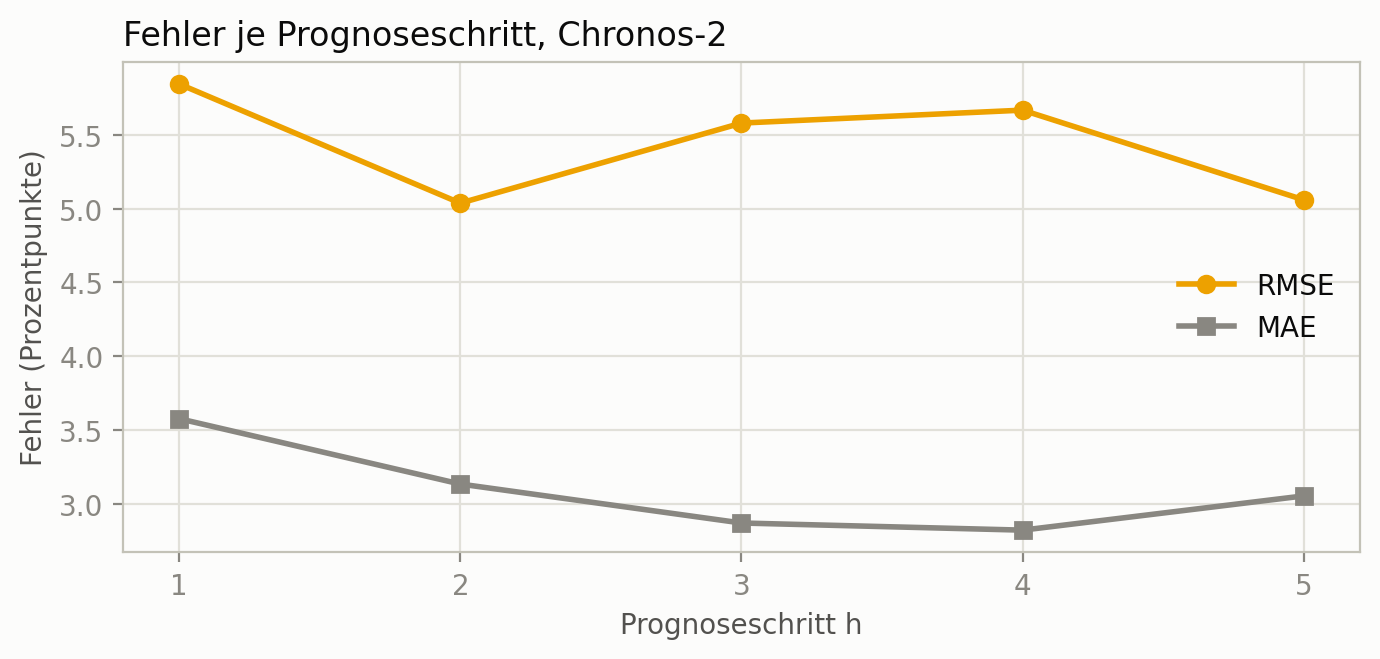

In [50]:
def summarize_by_horizon(preds: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for h, g in preds.groupby("h"):
        rows.append({
            "h": int(h),
            "RMSE": evaluation.rmse(g["y_true"], g["y_pred"]),
            "MAE": evaluation.mae(g["y_true"], g["y_pred"]),
            "coverage_80": evaluation.interval_coverage(g["y_true"], g["q10"], g["q90"]),
            "n_forecasts": len(g),
        })
    return pd.DataFrame(rows).sort_values("h").reset_index(drop=True)


by_h = summarize_by_horizon(preds_chronos2)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(by_h["h"], by_h["RMSE"], marker="o",
        color=plotting.MODEL_COLORS["chronos2"], label="RMSE")
ax.plot(by_h["h"], by_h["MAE"], marker="s", color=plotting.MUTED, label="MAE")
ax.set_xlabel("Prognoseschritt h")
ax.set_ylabel("Fehler (Prozentpunkte)")
ax.set_title("Fehler je Prognoseschritt, Chronos-2", loc="left", color=plotting.INK)
ax.set_xticks(by_h["h"])
ax.legend(frameon=False)
fig.tight_layout()
by_h

### 5.4 Güte je Ländergruppe

MASE nach Einkommensgruppe und Region. So wird sichtbar, ob das Modell in bestimmten
Ländergruppen systematisch besser oder schlechter abschneidet.

In [51]:
def mase_by_group(preds: pd.DataFrame, panel: pd.DataFrame,
                  static: pd.DataFrame, group_col: str) -> pd.DataFrame:
    p = preds.merge(static[["country", group_col]], on="country", how="left")
    rows = []
    for grp, g in p.groupby(group_col):
        mases = []
        for (c, o), gg in g.groupby(["country", "origin_year"]):
            y_train = panel.loc[(panel["country"] == c) & (panel["year"] <= o), TARGET]
            mases.append(evaluation.mase(gg["y_true"], gg["y_pred"], y_train))
        rows.append({group_col: grp, "MASE": np.nanmean(mases),
                     "n_laender": g["country"].nunique()})
    return pd.DataFrame(rows).sort_values("MASE").reset_index(drop=True)


display(mase_by_group(preds_chronos2, panel, static, "income_group"))
display(mase_by_group(preds_chronos2, panel, static, "region"))

,income_group,MASE,n_laender
0,Low income,0.600996,11
1,Lower middle income,0.619293,27
2,Upper middle income,0.949910,32
3,High income,0.969918,46


,region,MASE,n_laender
0,Sub-Saharan Africa,0.584617,27
1,"Middle East, North Africa, Afghanistan & Pakistan",0.663674,15
2,South Asia,0.721176,5
3,North America,0.764426,2
4,East Asia & Pacific,0.887299,20
5,Latin America & Caribbean,1.022822,20
6,Europe & Central Asia,1.084010,27


### 5.5 Prognose gegenüber tatsächlichem Verlauf

Für ausgewählte Länder wird die Prognose gegen den tatsächlichen Verlauf gezeigt,
inklusive des q10-bis-q90-Bands. Als Vergleichslinie ist die **Klimatologie** eingezeichnet,
die maßgebliche Baseline aus Abschnitt 5.1. So wird unmittelbar sichtbar, wie weit sich
Chronos-2 vom schlichten historischen Mittel entfernt, in aller Regel nämlich wenig. Der
Random Walk mit Drift bleibt hier bewusst außen vor, er würde nur eine zweite graue Linie
ohne eigenen Erkenntnisgewinn eintragen.

Bewusst werden **zwei** Folds gegenübergestellt: ein ruhiger Fold (Training bis 2014,
Prognose 2015 bis 2019) und der finale COVID-Fold (Training bis 2019, Prognose 2020 bis
2024). Nur den COVID-Fold zu zeigen, würde das Modell unfair schlecht darstellen, da der
Einbruch 2020 aus der Vergangenheit heraus nicht prognostizierbar ist.

--- ruhiger Fold: Training bis 2014, Prognose 2015 bis 2019 ---


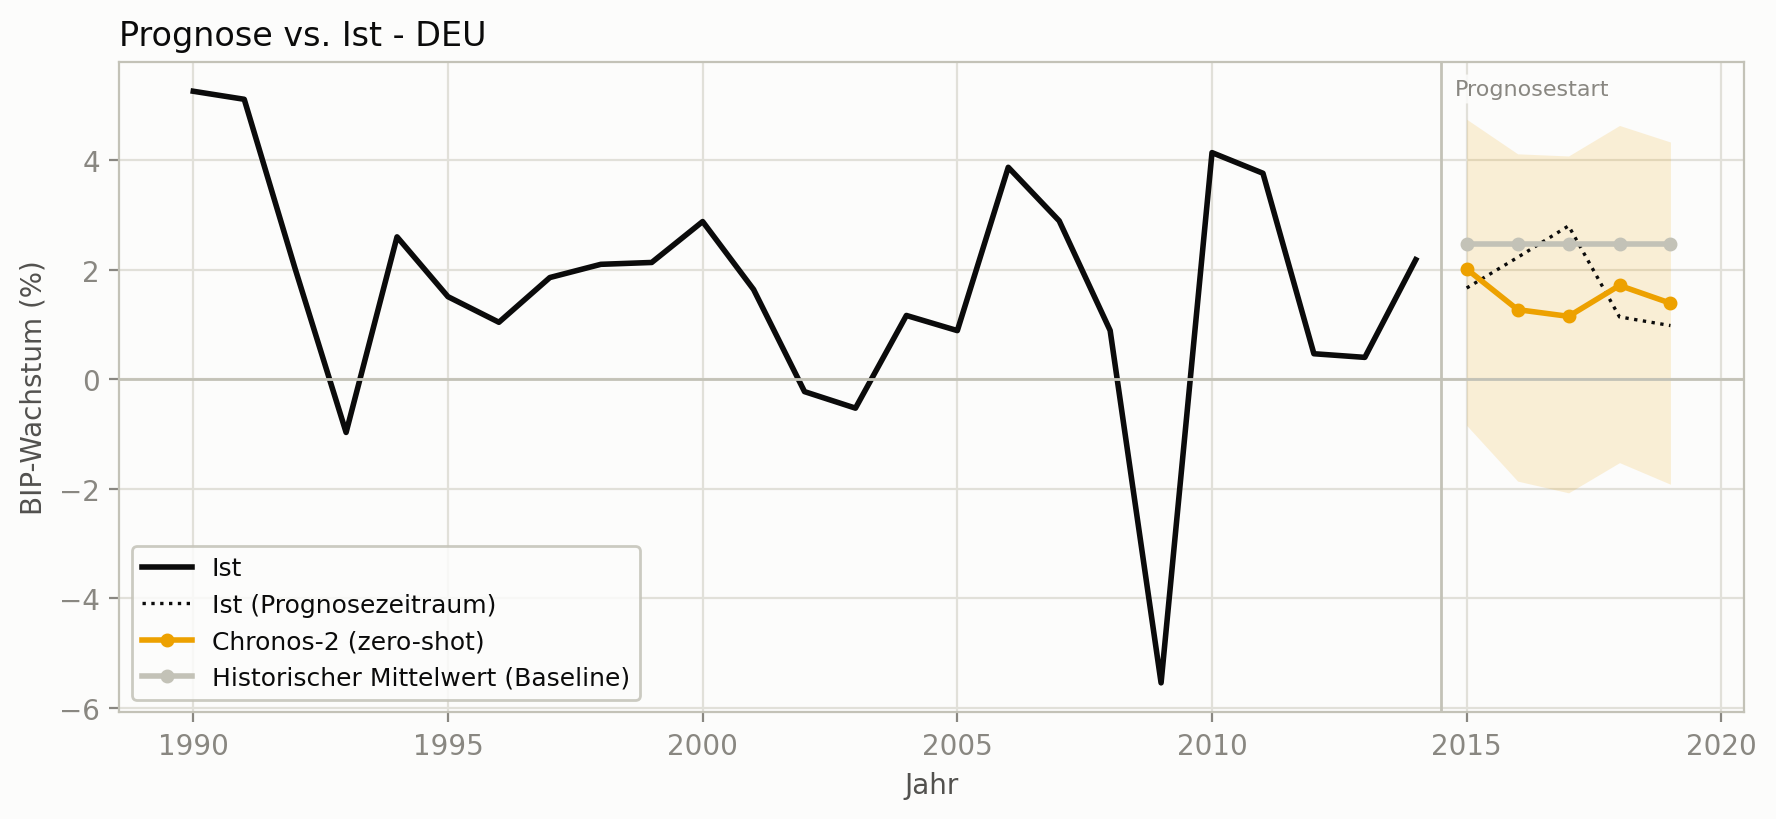

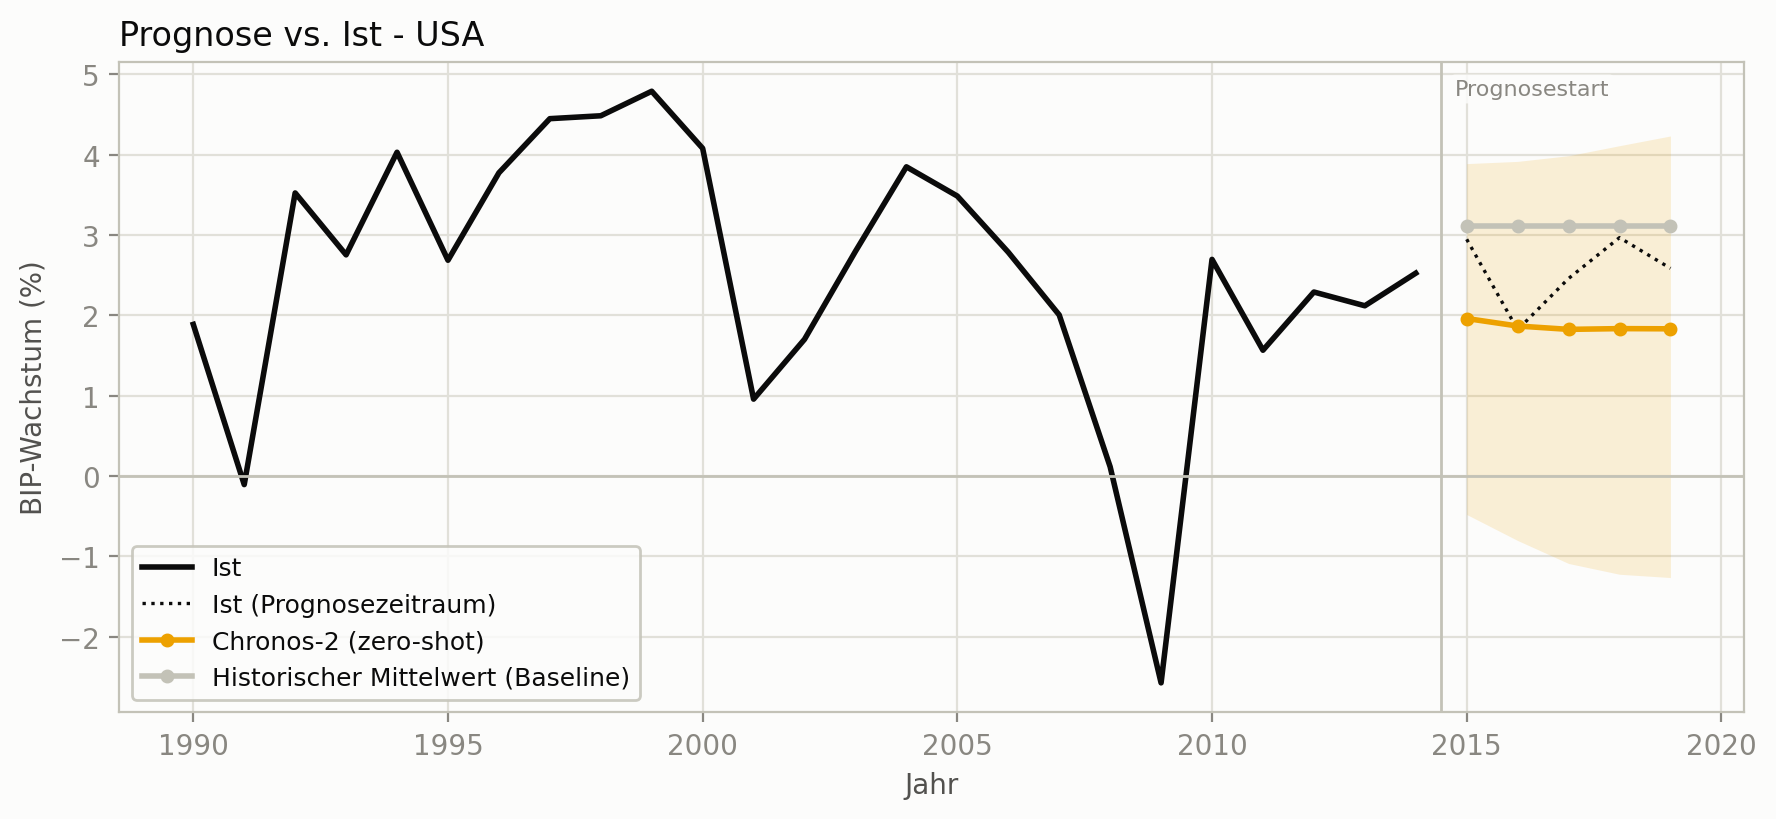

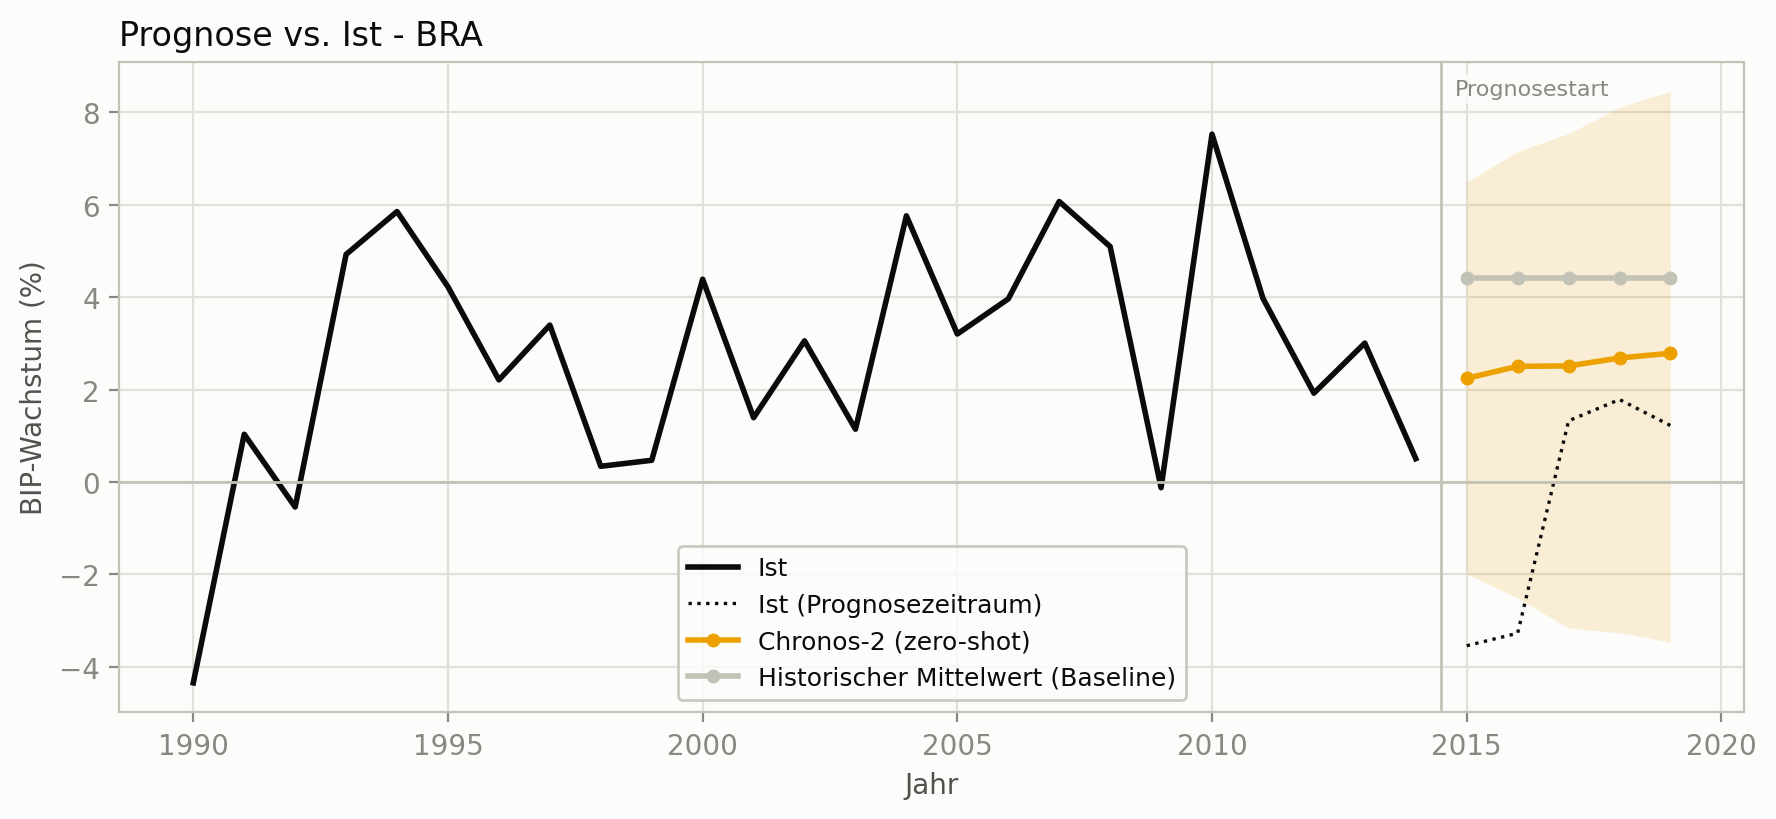

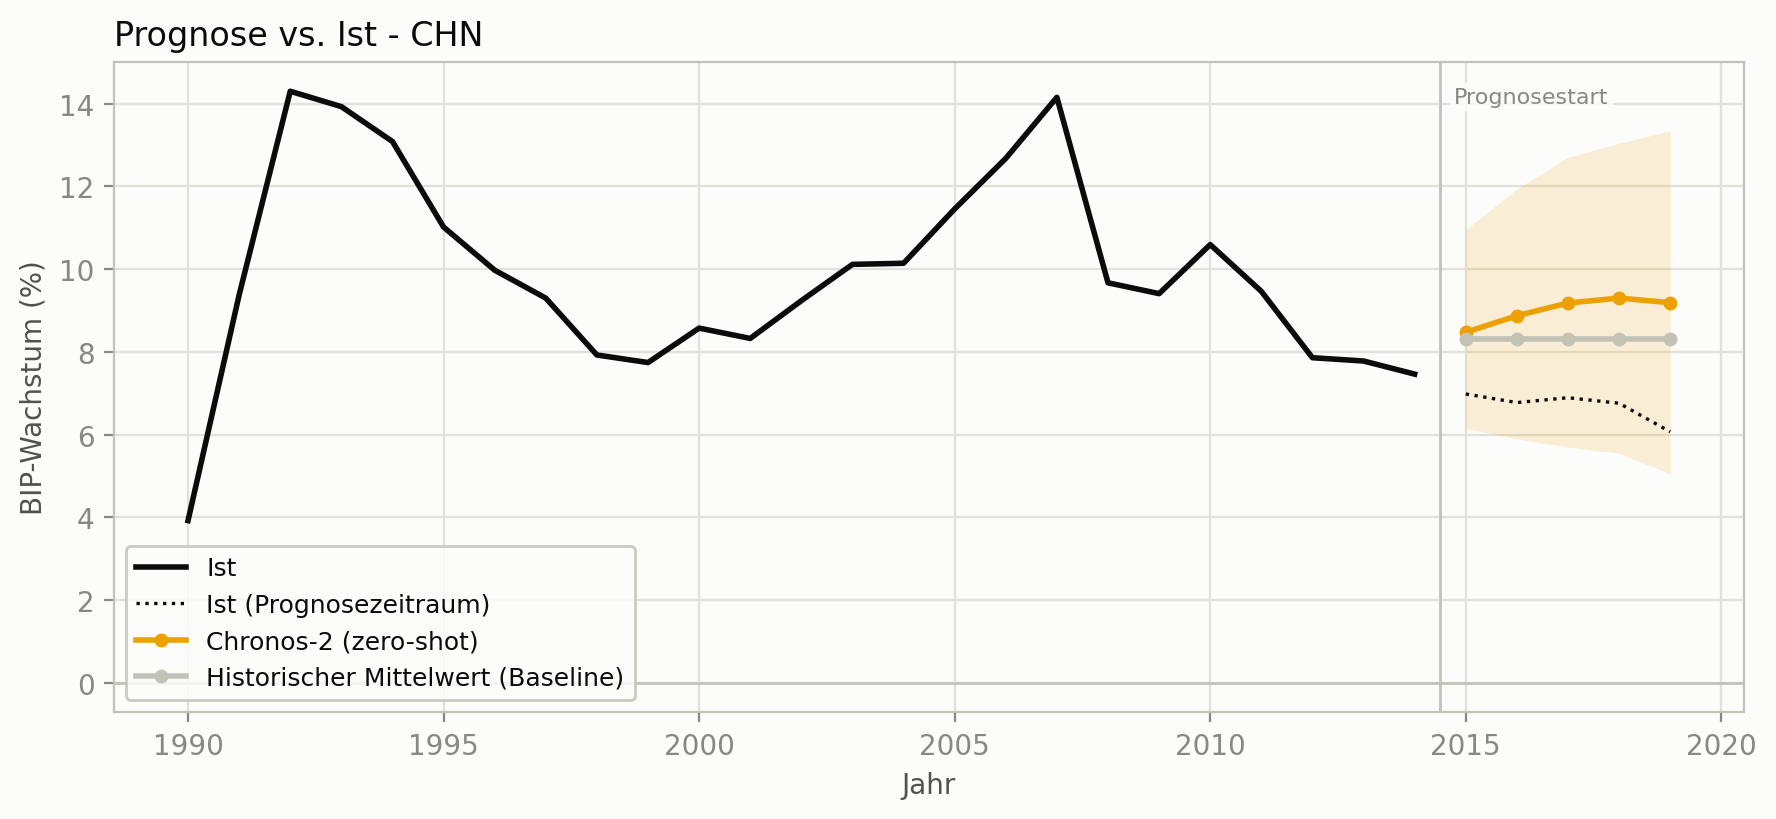

--- COVID-Fold: Training bis 2019, Prognose 2020 bis 2024 ---


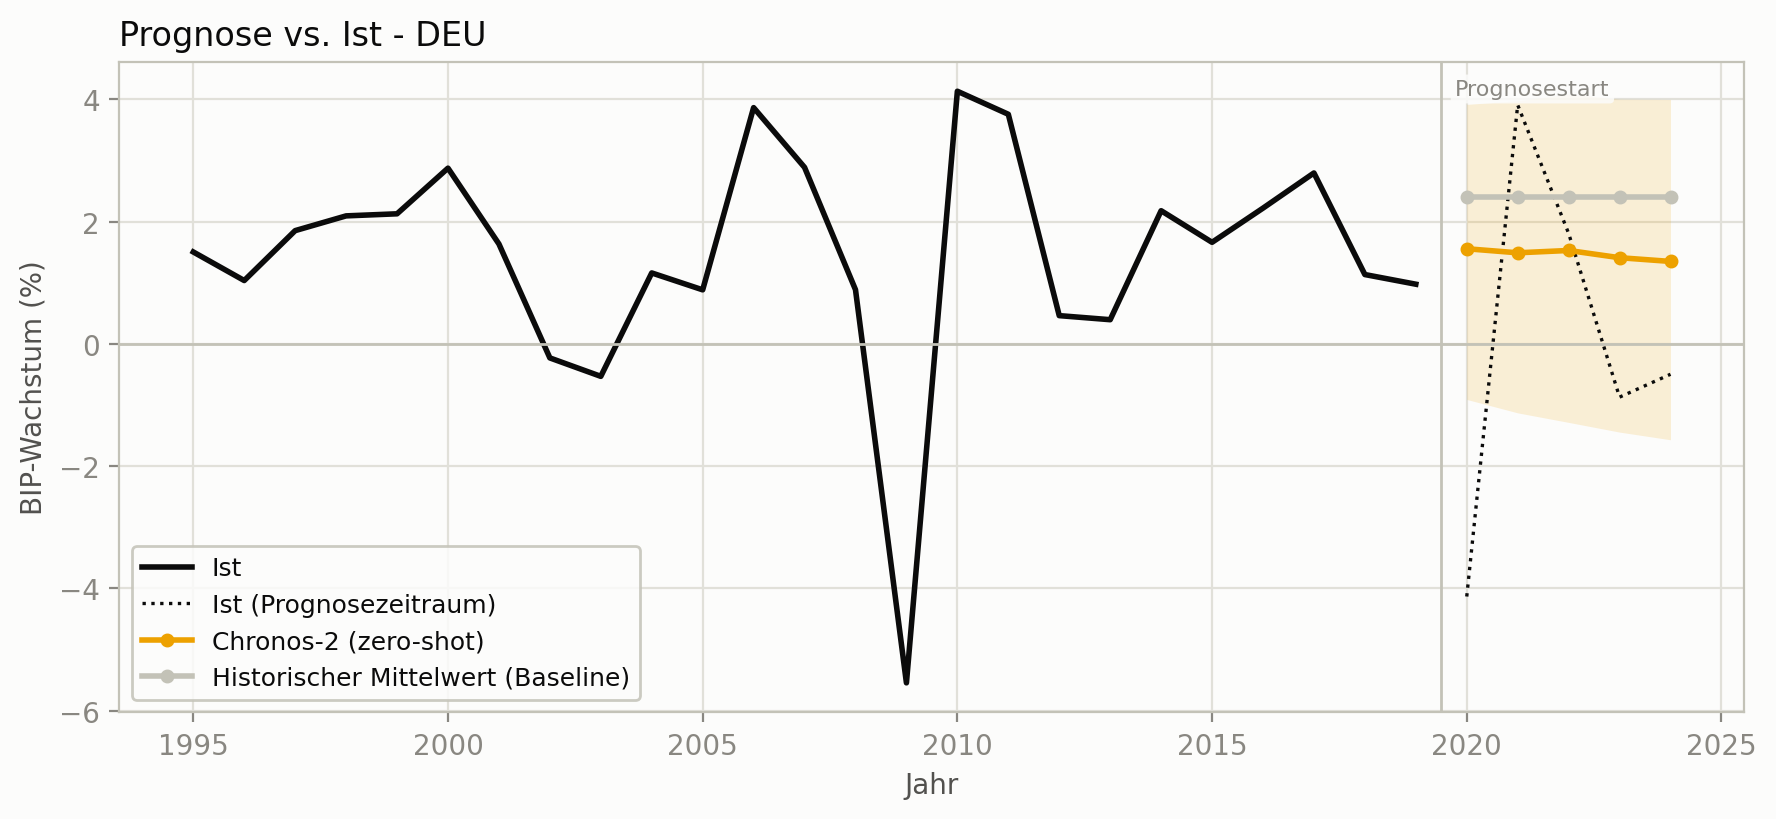

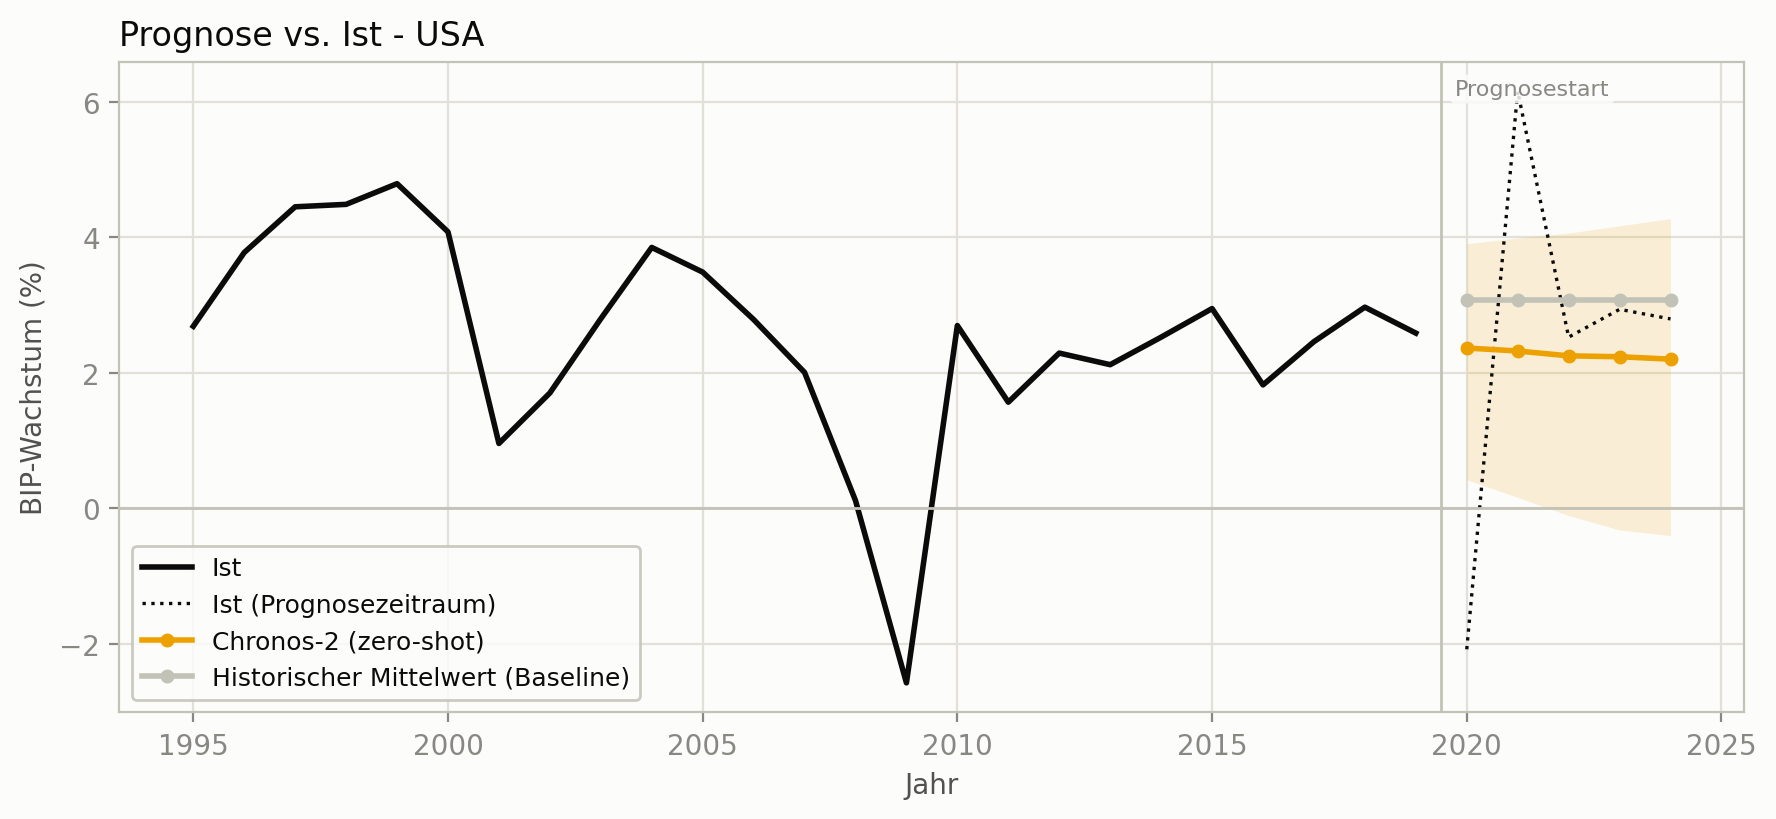

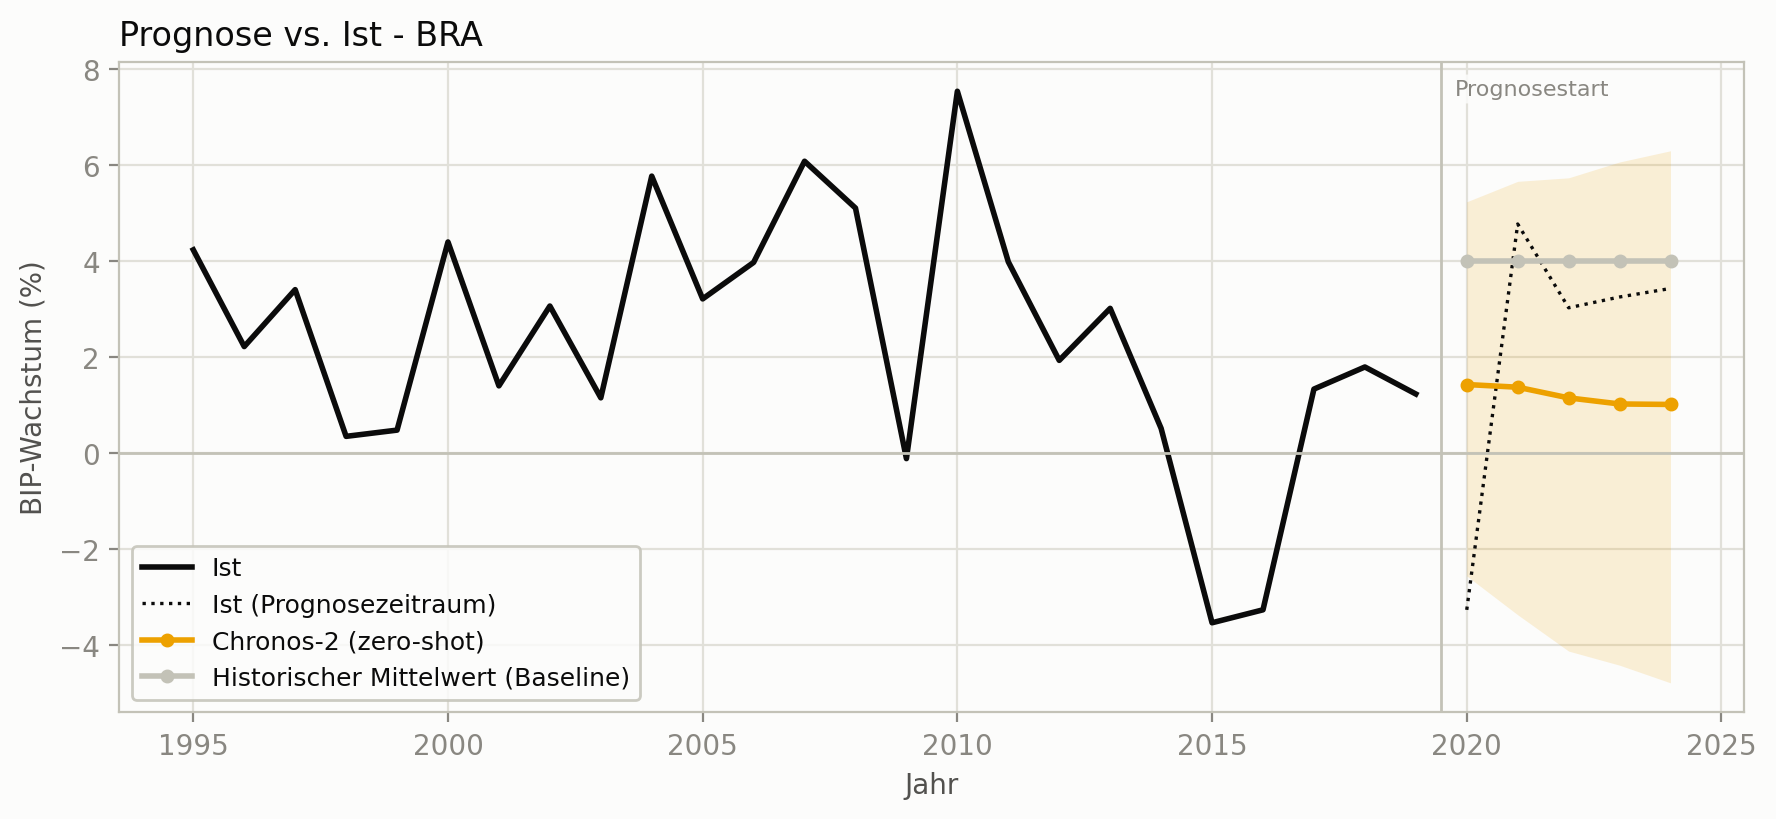

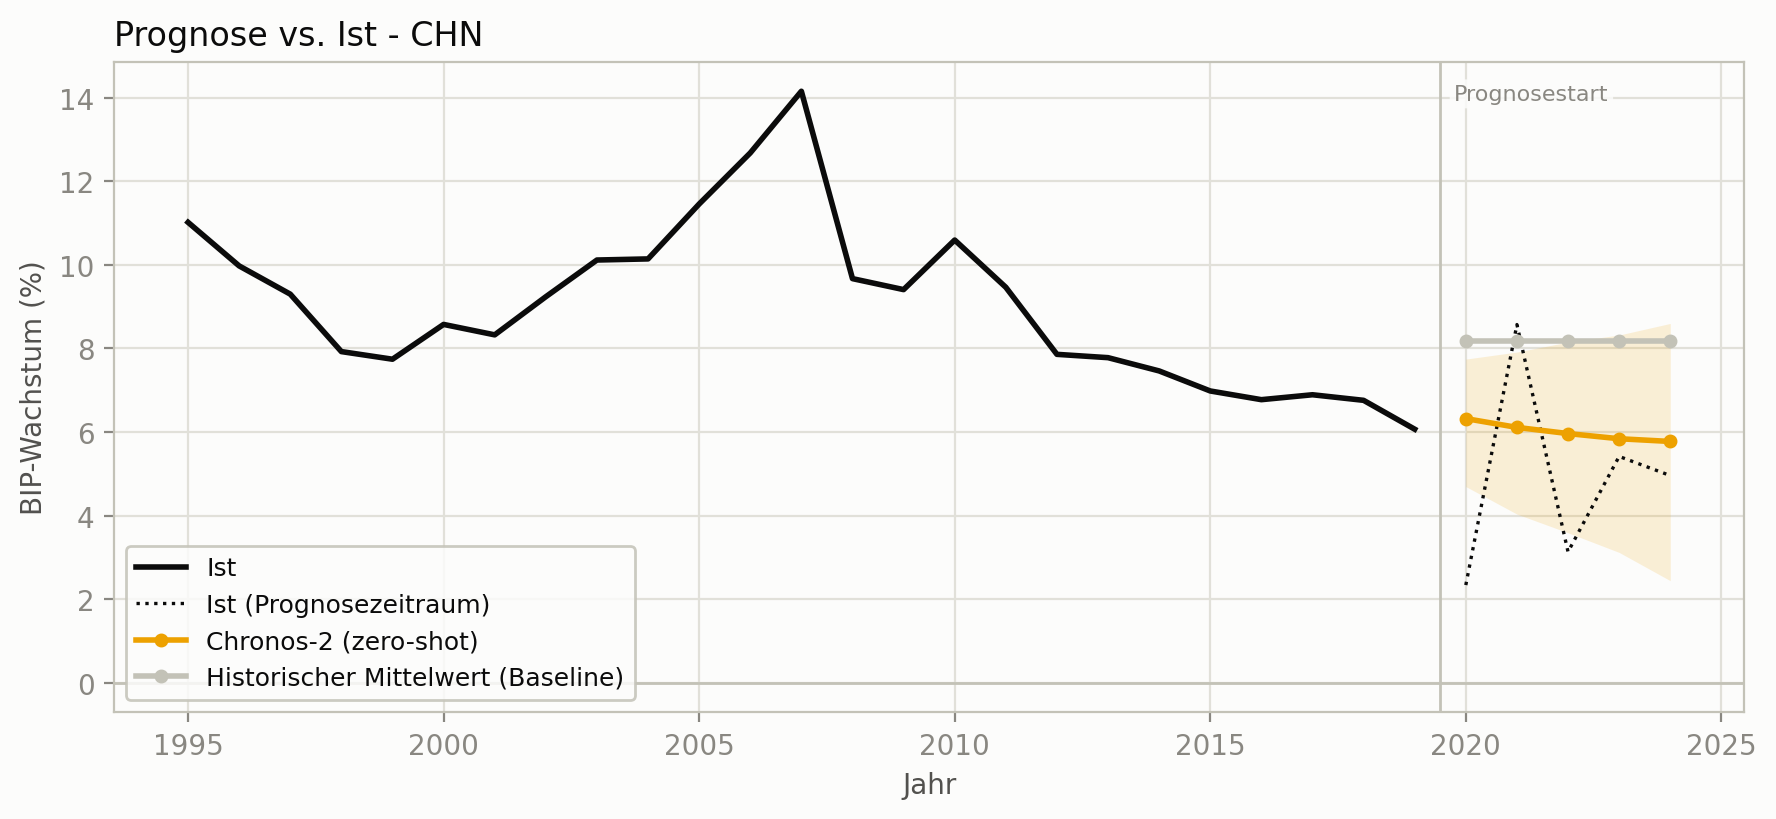

In [52]:
example_countries = [c for c in ["DEU", "USA", "BRA", "CHN"]
                     if c in preds_chronos2["country"].unique()]

# Klimatologie (preds_mean aus Abschnitt 4.5) als Vergleichslinie mitzeichnen.
# Sie hat keine Quantile, erscheint also als flache Linie ohne Band, waehrend
# nur Chronos-2 sein q10-bis-q90-Band behaelt.
preds_plot = pd.concat([preds_chronos2, preds_mean], ignore_index=True)

for origin_year, label in [(config.BACKTEST_ORIGINS[-1], "ruhiger Fold"),
                           (config.FINAL_ORIGIN, "COVID-Fold")]:
    print(f"--- {label}: Training bis {origin_year}, "
          f"Prognose {origin_year + 1} bis {origin_year + config.HORIZON} ---")
    train_o = panel[panel["year"] <= origin_year]
    preds_o = preds_plot[preds_plot["origin_year"] == origin_year]
    for c in example_countries:
        plotting.plot_forecast(train_o, preds_o, c, models=["chronos2", "mean"])
    plt.show()

### 5.6 Kalibrierung der Unsicherheit

Die 80-Prozent-Abdeckung sollte nahe 0,80 liegen. Zusätzlich wird der Anteil sich
kreuzender Quantile (q10 größer als q90) geprüft. Er sollte praktisch null sein.

Wichtig ist die **bedingte** Kalibrierung: Ein über alle Folds gemittelter Wert nahe 0,80
kann eine deutliche Fehlkalibrierung unter Strukturbrüchen verdecken. Die Aufschlüsselung
je Origin zeigt daher gezielt, wie stark die Abdeckung im COVID-Fold einbricht, wenn die
Intervalle den plötzlichen Einbruch nicht abdecken.

In [53]:
def quantile_crossing_rate(preds: pd.DataFrame) -> float:
    d = preds.dropna(subset=["q10", "q90"])
    return float((d["q10"] > d["q90"]).mean())


cov = evaluation.interval_coverage(preds_chronos2["y_true"],
                                   preds_chronos2["q10"], preds_chronos2["q90"])
print(f"80-Prozent-Intervall-Abdeckung (gesamt): {cov:.1%} (Soll etwa 80 Prozent)")
print(f"Anteil sich kreuzender Quantile (q10 > q90): "
      f"{quantile_crossing_rate(preds_chronos2):.2%}")
print(f"Pinball-Loss q10: "
      f"{evaluation.pinball_loss(preds_chronos2['y_true'], preds_chronos2['q10'], 0.1):.3f}")
print(f"Pinball-Loss q90: "
      f"{evaluation.pinball_loss(preds_chronos2['y_true'], preds_chronos2['q90'], 0.9):.3f}")

# Bedingte Kalibrierung: Abdeckung je Origin (deckt den COVID-Einbruch auf)
cov_by_origin = (preds_chronos2.groupby("origin_year")
                 .apply(lambda g: evaluation.interval_coverage(
                     g["y_true"], g["q10"], g["q90"]))
                 .rename("coverage_80").reset_index())
print("\nAbdeckung je Origin:")
print(cov_by_origin.to_string(index=False))

80-Prozent-Intervall-Abdeckung (gesamt): 84.3% (Soll etwa 80 Prozent)
Anteil sich kreuzender Quantile (q10 > q90): 0.00%
Pinball-Loss q10: 0.959
Pinball-Loss q90: 0.801

Abdeckung je Origin:
 origin_year  coverage_80
        1999     0.896552
        2004     0.839655
        2009     0.896552
        2014     0.934483
        2019     0.648276


### 5.7 Residualdiagnostik

Die gemeinsame Out-of-sample-Residualdiagnostik aus `src/evaluation.py`, identisch zu den
übrigen Modell-Notebooks: Fehler nach Jahr und Prognosebereich, Verteilung, Q-Q-Plot,
Fehlerkorrelation nach Horizontabstand und Residuen nach Horizont.

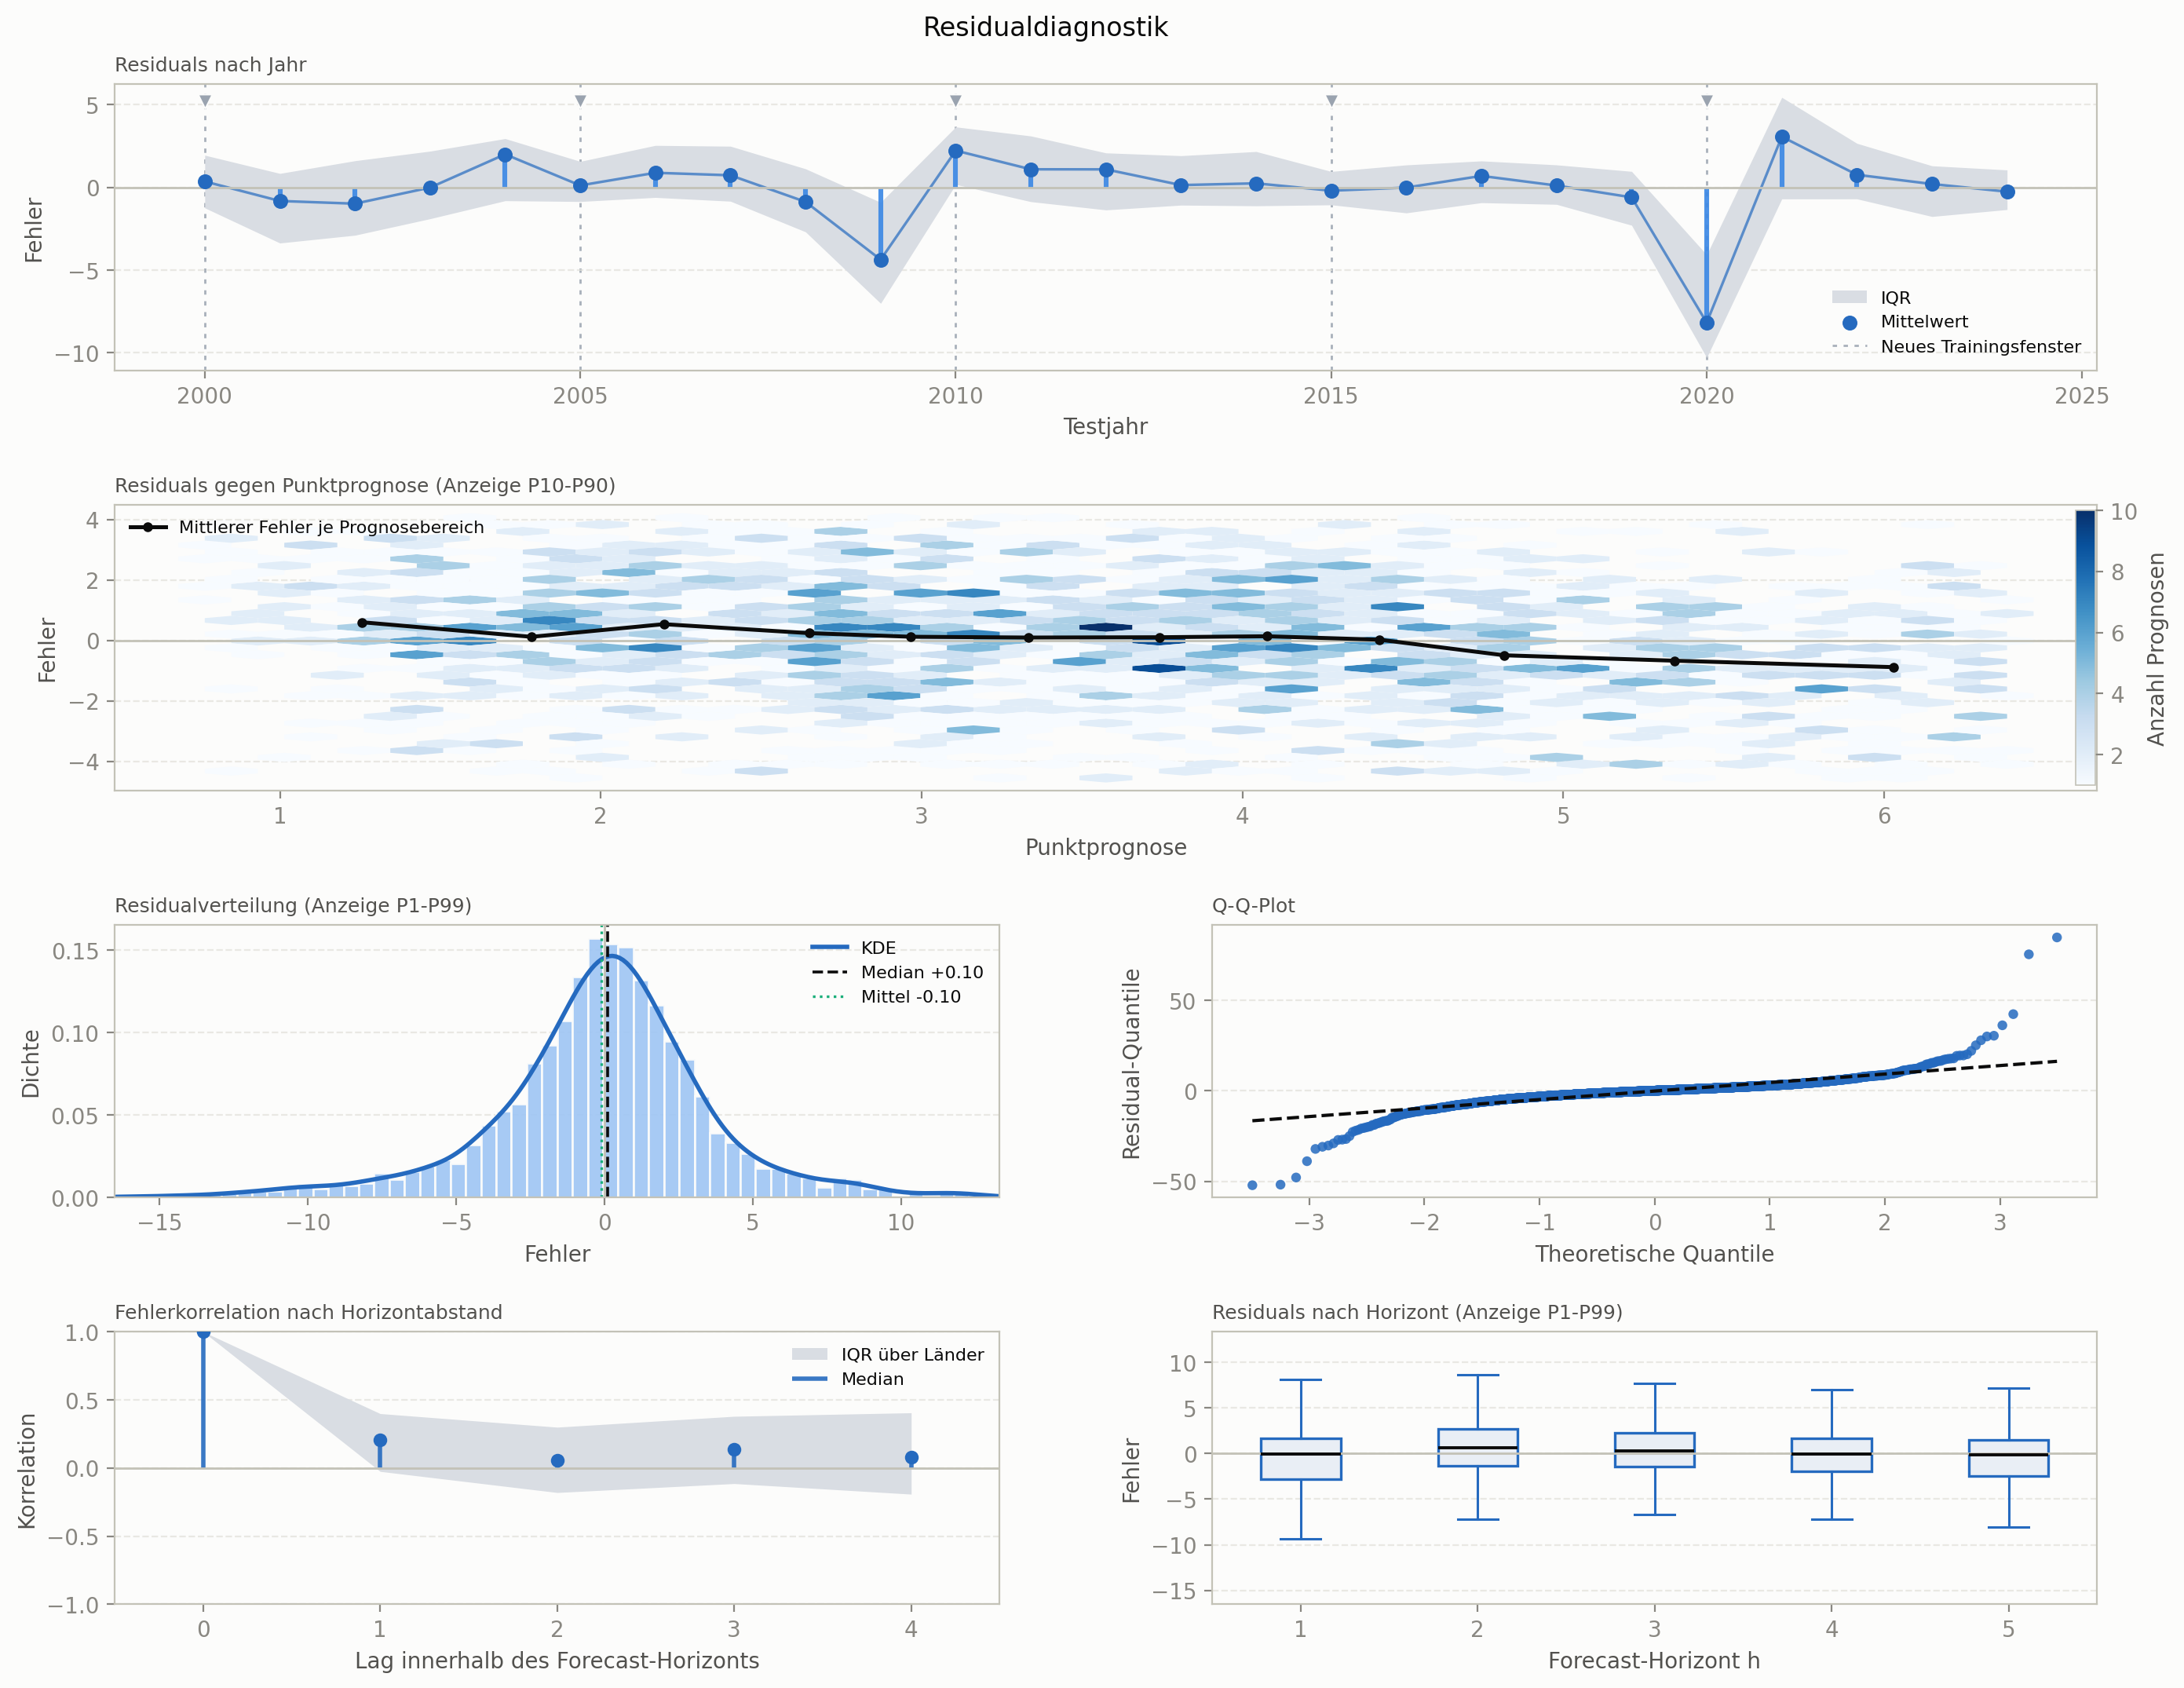

In [54]:
evaluation.plot_residual_diagnostics(preds_chronos2)
plt.show()

### 5.8 Mehrwert der Kovariaten

Der gepaarte Vergleich der MASE je Kombination aus Land und Origin zwischen der
covariate-informierten und der univariaten Variante zeigt, ob die exogenen Treiber im
Zero-Shot-Fall messbar helfen.

Die Wahl der Testebene entscheidet hier über das Ergebnis, deshalb werden beide berichtet.
Der Wilcoxon-Test behandelt jede der 580 Kombinationen als unabhängige Beobachtung. Diese
Annahme ist zu optimistisch, denn alle Länder eines Folds teilen dieselben fünf Testjahre
und dasselbe globale Makroumfeld. `clustered_forecast_test` mittelt die Differenzen deshalb
zuerst je Origin und testet dann die fünf Clustermittelwerte gegen null. Das ist der
konservative Gegentest.

Wie die Ausgabe zeigt, überlebt der Effekt diesen Gegentest nicht. Gepoolt ist er
signifikant, geclustert nicht, und die Origin-Mittelwerte sind nicht einmal im Vorzeichen
einheitlich. Die belastbare Aussage lautet daher: Die Kovariaten helfen im Zero-Shot-Fall
nicht erkennbar, ein systematischer Schaden lässt sich aber ebenso wenig nachweisen. Bei
fünf Clustern bedeutet ein nicht signifikantes Ergebnis nicht "kein Effekt", sondern "mit
dieser Zahl an Origins nicht nachweisbar".

In [55]:
if preds_chronos2_uni is not None:
    def per_unit_mase(preds: pd.DataFrame, panel: pd.DataFrame) -> pd.Series:
        vals = {}
        for (c, o), g in preds.groupby(["country", "origin_year"]):
            y_train = panel.loc[(panel["country"] == c) & (panel["year"] <= o), TARGET]
            vals[(c, o)] = evaluation.mase(g["y_true"], g["y_pred"], y_train)
        return pd.Series(vals)

    m_cov = per_unit_mase(preds_chronos2, panel)
    m_uni = per_unit_mase(preds_chronos2_uni, panel)
    common = m_cov.index.intersection(m_uni.index)
    test = evaluation.paired_forecast_test(m_cov.loc[common], m_uni.loc[common])
    # Konservativer Gegentest: erst je Origin mitteln, dann testen. Alle Länder
    # eines Folds teilen dieselben Testjahre und dasselbe Makroumfeld, sind also
    # nicht unabhängig.
    clustered = evaluation.clustered_forecast_test(
        m_cov.loc[common], m_uni.loc[common], [o for _, o in common])

    print(f"MASE covariate-informiert: {m_cov.loc[common].mean():.3f}")
    print(f"MASE univariat           : {m_uni.loc[common].mean():.3f}")
    print(f"Mittlere Differenz (cov - uni): {test['mean_diff']:+.3f} "
          f"(negativ = Kovariaten helfen)")
    print(f"\ngepoolt über {test['n_pairs']} Paare : "
          f"Median {test['median_diff']:+.3f}, Wilcoxon p = {test['wilcoxon_p']:.4f}")
    print(f"geclustert auf {clustered['n_clusters']} Origins: "
          f"t-Test p = {clustered['ttest_p']:.4f}")
    print("  Origin-Mittelwerte der Differenz: "
          + ", ".join(f"{v:+.3f}" for v in clustered["cluster_means"]))

    # MASE je Origin für beide Varianten nebeneinander, damit sichtbar wird,
    # in welchen Zeitfenstern die Kovariaten helfen und in welchen nicht.
    o_cov = summarize_by_origin(preds_chronos2, panel).set_index("origin_year")["MASE"]
    o_uni = summarize_by_origin(preds_chronos2_uni, panel).set_index("origin_year")["MASE"]
    ablation = pd.DataFrame({"MASE_covariates": o_cov, "MASE_univariat": o_uni})
    ablation["Delta (cov - uni)"] = ablation["MASE_covariates"] - ablation["MASE_univariat"]
    display(ablation.round(3))
else:
    print("Keine univariate Ablation vorhanden (RUN_UNIVARIATE_ABLATION = False).")

MASE covariate-informiert: 0.848
MASE univariat           : 0.826
Mittlere Differenz (cov - uni): +0.022 (negativ = Kovariaten helfen)

gepoolt über 580 Paare : Median +0.007, Wilcoxon p = 0.0053
geclustert auf 5 Origins: t-Test p = 0.1750
  Origin-Mittelwerte der Differenz: +0.058, +0.042, -0.018, +0.013, +0.012


,MASE_covariates,MASE_univariat,Delta (cov - uni)
origin_year,,,
1999,0.779,0.721,0.058
2004,0.844,0.802,0.042
2009,0.805,0.822,-0.018
2014,0.576,0.563,0.013
2019,1.235,1.223,0.012


## 6 Aggregierte Weltreihe

Die Abschnitte 4 und 5 prognostizieren 116 Länder **einzeln**. Genau dort setzt die
Prognoseliteratur den Hebel an: Für einzelne Volkswirtschaften ist BIP-Wachstum über einen
Fünfjahreshorizont kaum prognostizierbar, weil der Großteil der Varianz aus
länderspezifischen, unvorhersehbaren Schocks stammt. Die Diagnostik in Abschnitt 5 zeigt
dasselbe Bild: eine mediane Lag-1-Autokorrelation von rund 0,27 und ein MASE nahe 0,85, also
nur ein knapper Vorsprung vor der naiven Prognose.

Auf dem **Aggregat** ist die Lage anders. Länderspezifische Schocks sind zu einem großen
Teil idiosynkratisch und mitteln sich beim Aufsummieren heraus. Übrig bleibt der gemeinsame
globale Konjunkturzyklus. Dieser Abschnitt baut deshalb eine echte Weltreihe und
prognostiziert sie mit demselben Zero-Shot-Protokoll.

Drei Wege führen zu einer Weltprognose, alle drei werden hier verglichen:

| Weg | Vorgehen |
|---|---|
| **Top-down** | Weltreihe direkt aggregieren und als eine Reihe prognostizieren |
| **Top-down + Kontext** | wie oben, aber mit den 116 Länderreihen als Kontext (`cross_learning=True`) |
| **Bottom-up** | die 116 Länderprognosen aus Abschnitt 4 BIP-gewichtet zur Welt aufsummieren |

Der Vergleich von Bottom-up und Top-down ist die klassische Frage der
Prognose-Reconciliation: Ist es besser, das Aggregat direkt zu modellieren, oder die Teile
einzeln und dann zu addieren?

### 6.1 Konstruktion der Weltreihe

Die Konstruktion liegt in `src.data_utils.build_world_panel()`, damit Notebook 05 exakt
dieselbe Weltreihe verwendet. Hier wird sie nur aufgerufen. Die Begründung der Gewichtung
steht im Docstring der Funktion und zusammengefasst hier.

Wachstumsraten darf man **nicht** ungewichtet mitteln, denn Tuvalu zählte sonst so viel wie die
USA. Die Weltreihe wird deshalb aus BIP-Niveaus aufgebaut:

1. Reales BIP je Land, `gdp_level = gdp_pc * population`, beides in konstanten Preisen
   (2015 US$) aus den WDI-Rohdaten. Das Modell-Panel enthält diese Spalten nicht mehr,
   weil Notebook 01 sie als reine Referenzgrößen entfernt. Sie werden hier direkt aus
   `data/raw/wdi_raw_long.csv` nachgeladen.
2. Weltwachstum als Quotient der Summen,
   $g^{\text{Welt}}_t = \sum_i \text{BIP}_{i,t} \big/ \sum_i \text{BIP}_{i,t-1} - 1$.

Entscheidend ist dabei die **paarweise Stichprobe**: In die Summe eines Jahres gehen nur
Länder ein, die sowohl in $t-1$ als auch in $t$ ein BIP-Niveau haben. Sonst würde der
Eintritt eines Landes in die Datenbasis als Wachstumssprung erscheinen. Ab 1989 liegen für
alle 116 Länder Werte vor, in den Testfenstern (ab 2000) ist die Zusammensetzung also
ohnehin konstant.

Die Kovariaten werden analog aggregiert, jeweils mit der ökonomisch passenden Gewichtung:
Bevölkerungswachstum aus der Summe der Bevölkerung, `working_age_share`
bevölkerungsgewichtet, die Quoten `investment_gdp` und `trade_gdp` BIP-gewichtet. Die
Inflation wird erst je Land gedämpft ($\text{sign}(x)\log(1+|x|)$, wie in Notebook 01) und
dann BIP-gewichtet gemittelt, denn andernfalls würde eine einzelne Hyperinflation den Weltwert
dominieren. So trägt die Weltreihe exakt dieselben Spaltennamen wie das Länderpanel und
läuft ohne Anpassung durch `build_fold_frames`.

In [56]:
# Weltreihe und BIP-Niveaus kommen aus src, damit Notebook 05 exakt dieselbe
# Konstruktion nutzt. Details der Gewichtung: data_utils.build_world_panel.
world_panel, gdp_levels = data_utils.build_world_panel(panel)
WORLD_ID = config.WORLD_ID

print(f"Weltreihe: {world_panel['year'].min()} bis {world_panel['year'].max()}, "
      f"{len(world_panel)} Jahre")
print(f"Länder je Jahr: {world_panel['n_countries'].min()} bis "
      f"{world_panel['n_countries'].max()} (ab {config.WORLD_COMPLETE_SINCE} "
      "durchgängig 116)")
print(f"Weltwachstum: Mittel {world_panel[TARGET].mean():.2f} %, "
      f"Std {world_panel[TARGET].std():.2f} pp")

# Die Weltreihe trägt exakt die Spaltennamen des Länderpanels und läuft
# deshalb ohne Anpassung durch build_fold_frames.
assert all(c in world_panel.columns
           for c in [TARGET] + KNOWN_FUTURE + PAST_LAGGED + [CRISIS])
world_panel.head()

Weltreihe: 1961 bis 2024, 64 Jahre
Länder je Jahr: 85 bis 116 (ab 1989 durchgängig 116)
Weltwachstum: Mittel 3.46 %, Std 1.68 pp


,country,year,gdp_growth,pop_growth,working_age_share,log_gdp_pc_lag1,investment_gdp_lag1,trade_gdp_lag1,inflation_log_lag1,is_global_crisis,n_countries,world_gdp
0,WLD,1961,3.937181,1.271784,57.551324,NaN,NaN,NaN,NaN,0,85,1.024305e+13
1,WLD,1962,5.380735,1.745430,57.435306,8.243146,22.857724,28.593773,1.067094,0,89,1.079420e+13
2,WLD,1963,5.151358,2.145990,57.177817,8.278252,22.138556,26.768732,1.244403,0,89,1.135025e+13
3,WLD,1964,6.597387,2.108870,56.964150,8.307250,22.870143,28.032614,1.270182,0,89,1.209907e+13
4,WLD,1965,5.563407,2.083065,56.858036,8.350269,23.863308,27.976844,1.289532,0,89,1.278063e+13


#### Validierung

Zwei unabhängige Prüfungen. Erstens der Abgleich mit den offiziellen Weltwerten der
Weltbank (`NY.GDP.MKTP.KD.ZG` für `WLD`): Kleine Abweichungen sind zu erwarten, weil unsere
Basis 116 gefilterte Länder umfasst und nicht alle rund 200 Volkswirtschaften. Zweitens ein
Reproduktionstest: Aggregiert man die **tatsächlichen** Länderwachstumsraten bottom-up
(dieselbe Rechenvorschrift, die in Abschnitt 6.3 auf die Prognosen angewandt wird), muss
wieder die direkt berechnete Weltreihe herauskommen. Damit ist sichergestellt, dass der
Vergleich von Bottom-up und Top-down nicht an unterschiedlichen Definitionen scheitert.

In [57]:
# 1) Abgleich mit den offiziellen Weltbank-Weltwerten
WB_WORLD_REFERENCE = {1998: 2.6, 2008: 1.9, 2009: -1.3,
                      2010: 4.5, 2020: -3.1, 2021: 6.3}
ref = pd.DataFrame({
    "Weltbank (alle Länder)": pd.Series(WB_WORLD_REFERENCE),
    "eigene Reihe (116)": world_panel.set_index("year")[TARGET].round(2),
}).dropna()
ref["Differenz"] = (ref["eigene Reihe (116)"] - ref["Weltbank (alle Länder)"]).round(2)
print("Abgleich mit den offiziellen Weltbank-Weltwerten (% p.a.):")
print(ref.to_string())
assert ref["Differenz"].abs().max() < 0.6, "Weltreihe weicht zu stark von der Referenz ab"

# 2) Reproduktionstest der Bottom-up-Rechenvorschrift
_actual = (panel[panel["year"] > min(ORIGINS)][["country", "year", TARGET]]
           .rename(columns={TARGET: "y_pred"}))
_actual = pd.concat(
    [_actual.assign(origin_year=o, h=_actual["year"] - o)
     for o in ORIGINS], ignore_index=True)
_actual = _actual[_actual["h"].between(1, config.HORIZON)]
_actual["model"] = "ist"   # aggregate_bottom_up gruppiert nach Modell


Abgleich mit den offiziellen Weltbank-Weltwerten (% p.a.):
      Weltbank (alle Länder)  eigene Reihe (116)  Differenz
1998                     2.6                2.77       0.17
2008                     1.9                1.95       0.05
2009                    -1.3               -1.36      -0.06
2010                     4.5                4.47      -0.03
2020                    -3.1               -2.79       0.31
2021                     6.3                6.57       0.27


In [58]:
# Bottom-up-Aggregation ebenfalls aus src: evaluation.aggregate_bottom_up
# gewichtet die Länderprognosen mit dem BIP-Niveau des Origin-Jahres (zur
# Prognosezeit bekannt, also leakage-frei) und schreibt sie fort.
_recon = evaluation.aggregate_bottom_up(
    _actual, gdp_levels, world_panel, model="reproduktion").dropna(subset=["y_true"])
_gap = (_recon["y_pred"] - _recon["y_true"]).abs().max()
print(f"Reproduktionstest: max. Abweichung bottom-up vs. direkte Weltreihe "
      f"{_gap:.4f} Prozentpunkte")
assert _gap < 0.1, "Bottom-up und direkte Weltreihe sind nicht konsistent"
print("OK: Beide Wege beschreiben dieselbe Größe, der Vergleich ist fair.")
print("\n(Die Restabweichung stammt daraus, dass das von der Weltbank gemeldete\n"
      " gdp_growth minimal von dem aus gdp_pc * population impliziten abweicht.)")

Reproduktionstest: max. Abweichung bottom-up vs. direkte Weltreihe 0.0235 Prozentpunkte
OK: Beide Wege beschreiben dieselbe Größe, der Vergleich ist fair.

(Die Restabweichung stammt daraus, dass das von der Weltbank gemeldete
 gdp_growth minimal von dem aus gdp_pc * population impliziten abweicht.)


### 6.2 Die Weltreihe im Bild

Der Kontrast zu den Länderreihen ist der eigentliche Punkt dieses Abschnitts: Das
Weltaggregat ist deutlich glatter, bleibt fast immer positiv und hat mit den Rezessionen
2009 und 2020 nur zwei markante Einbrüche.

Standardabweichung Weltreihe        : 1.68 pp
Standardabweichung Länder (Median) : 4.27 pp
Verhältnis: Aggregation dämpft die Schwankung um den Faktor 2.5


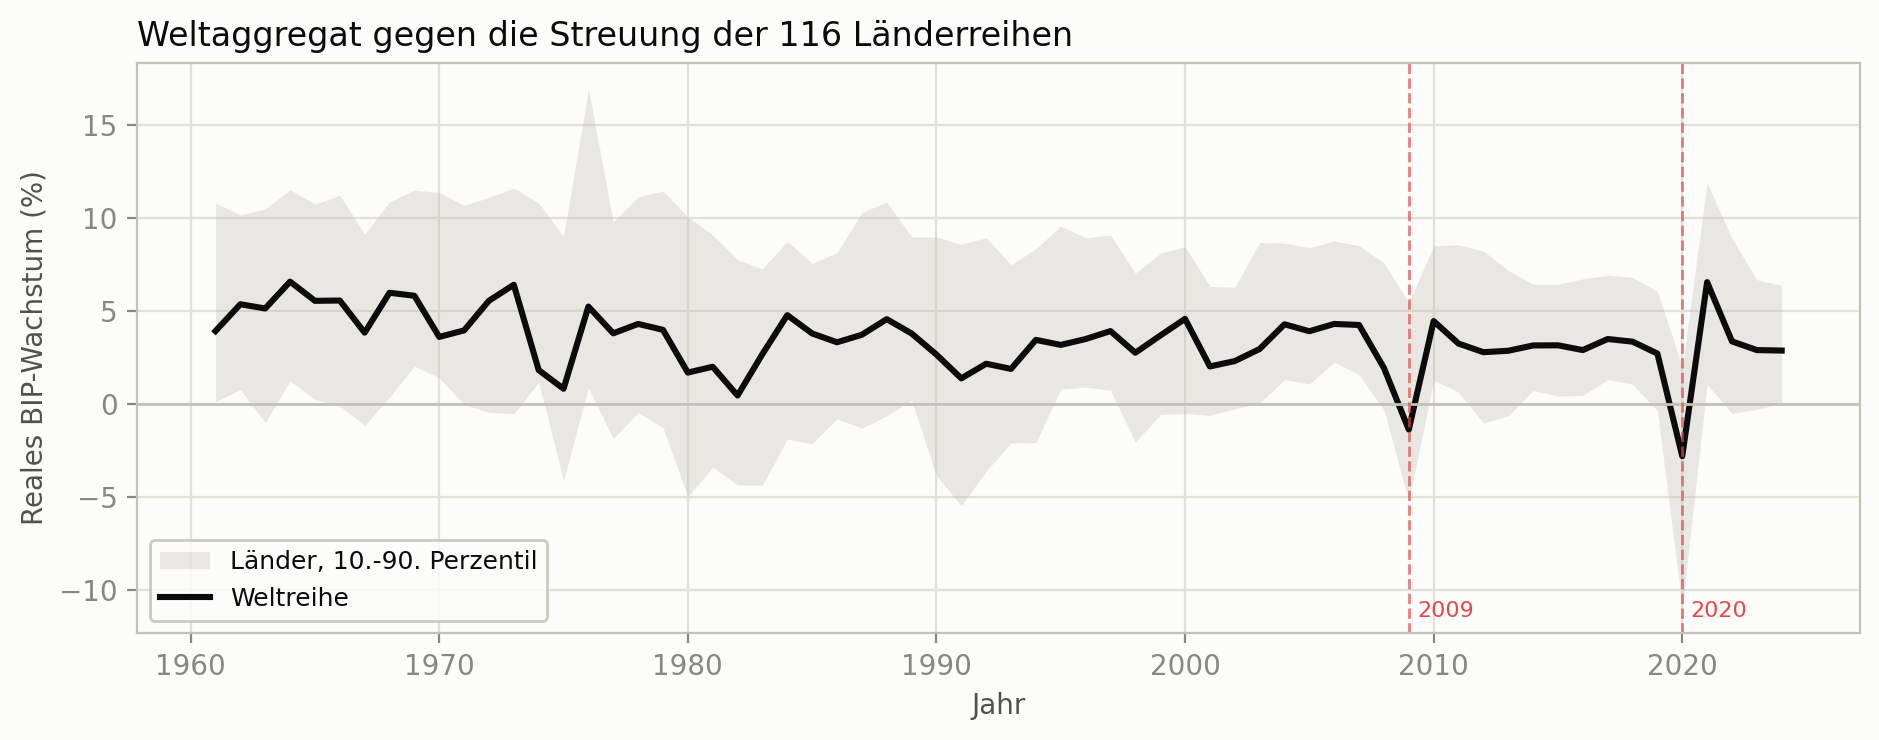

In [59]:
fig, ax = plt.subplots(figsize=(9.5, 3.8))

# Streuung der Länderreihen als Hintergrund (10-90-Perzentil je Jahr)
_spread = (panel.groupby("year")[TARGET]
           .quantile([0.1, 0.9]).unstack().dropna())
ax.fill_between(_spread.index, _spread[0.1], _spread[0.9],
                color=plotting.BASELINE, alpha=0.35, linewidth=0,
                label="Länder, 10.-90. Perzentil")

ax.plot(world_panel["year"], world_panel[TARGET],
        color=plotting.MODEL_COLORS["actual"], linewidth=2.2, label="Weltreihe")
ax.axhline(0, color=plotting.BASELINE, linewidth=1)
for crisis_year in (2009, 2020):
    ax.axvline(crisis_year, color=plotting.DIVERGING_NEG, linewidth=1,
               linestyle="--", alpha=0.7)
    ax.annotate(str(crisis_year), (crisis_year, ax.get_ylim()[0]),
                xytext=(3, 6), textcoords="offset points",
                fontsize=8, color=plotting.DIVERGING_NEG)

ax.set_xlabel("Jahr")
ax.set_ylabel("Reales BIP-Wachstum (%)")
ax.set_title("Weltaggregat gegen die Streuung der 116 Länderreihen",
             loc="left", color=plotting.INK)
plotting.add_legend(ax, loc="lower left")
fig.tight_layout()

_country_std = panel.groupby("country")[TARGET].std()
print(f"Standardabweichung Weltreihe        : {world_panel[TARGET].std():.2f} pp")
print(f"Standardabweichung Länder (Median) : {_country_std.median():.2f} pp")
print(f"Verhältnis: Aggregation dämpft die Schwankung um den Faktor "
      f"{_country_std.median() / world_panel[TARGET].std():.1f}")

### 6.3 Zero-Shot-Backtest der Weltreihe

Dasselbe Protokoll wie in Abschnitt 4: dieselben fünf Origins, derselbe Fünfjahreshorizont,
dieselben Kovariatenrollen. `build_fold_frames` wird unverändert wiederverwendet, denn die
Weltreihe trägt dieselben Spaltennamen und ist für die Funktion einfach ein Panel mit einem
einzigen Land.

Verglichen wird gegen **zwei** Baselines. Der Random Walk mit Drift ist die kanonische
Projektbaseline, für eine mittelwertrückkehrende Reihe wie das Weltaggregat aber zu schwach:
Er schreibt den letzten Wert samt Trend fort und scheitert deshalb nach jedem Ausreißerjahr.
Der historische Mittelwert, in der Prognoseliteratur die Klimatologie, ist hier der ehrliche
Bezugspunkt. Ein Modell muss beide schlagen, um Fähigkeit zu belegen. Ergänzt wird eine
Ablation ohne jede Kovariate, analog zu Abschnitt 4.4.

Für die Kontext-Variante werden Weltreihe und Länderpanel zu einem Rahmen mit 117 Reihen
verkettet und mit `cross_learning=True` übergeben. Prognostiziert wird alles, ausgewertet
nur die Weltreihe. Die zu prüfende Hypothese: Die Weltreihe hat nur gut 60 Beobachtungen,
und die Chronos-2-Dokumentation nennt genau kurzen Kontext als den Fall, in dem
Cross-Learning am ehesten hilft. Ob das hier zutrifft, ist eine empirische Frage. Die
Dokumentation weist ausdrücklich darauf hin, dass Cross-Learning die Güte nicht immer
verbessert.

In [60]:
def forecast_world(origin_year: int, model_name: str,
                   with_country_context: bool = False,
                   use_covariates: bool = True) -> pd.DataFrame:
    """Ein Weltprognose-Fold. with_country_context hängt die 116 Länderreihen
    als zusätzlichen Kontext an und aktiviert cross_learning."""
    source = (pd.concat([world_panel, panel], ignore_index=True)
              if with_country_context else world_panel)
    context_df, future_df = build_fold_frames(
        source, origin_year, use_covariates=use_covariates)
    pred_df = pipeline.predict_df(
        context_df, future_df=future_df if use_covariates else None,
        prediction_length=config.HORIZON,
        quantile_levels=config.QUANTILES,
        id_column="id", timestamp_column="timestamp", target="target",
        cross_learning=with_country_context,
    )
    result = results_from_prediction(pred_df, world_panel, origin_year, model_name)
    return result[result["country"] == WORLD_ID].copy()


t0 = time.time()
preds_world = pd.concat(
    [forecast_world(o, "chronos2_world") for o in ORIGINS], ignore_index=True)
preds_world_ctx = pd.concat(
    [forecast_world(o, "chronos2_world_ctx", with_country_context=True)
     for o in ORIGINS], ignore_index=True)

# Bottom-up aus den bereits vorliegenden Länderprognosen (Abschnitt 4)
preds_world_bu = evaluation.aggregate_bottom_up(
    preds_chronos2, gdp_levels, world_panel, model="chronos2_bottom_up")

# Ablation: dieselbe Top-down-Prognose ohne jede Kovariate
preds_world_uni = pd.concat(
    [forecast_world(o, "chronos2_world_uni", use_covariates=False)
     for o in ORIGINS], ignore_index=True)

# ZWEI Baselines. Der Random Walk mit Drift ist die kanonische Projektbaseline,
# für eine mittelwertrückkehrende Reihe wie das Weltaggregat aber zu schwach:
# Er schreibt den letzten Wert samt Trend fort und scheitert deshalb nach jedem
# Ausreißerjahr. Der historische Mittelwert ist hier der ehrliche Bezugspunkt.
preds_world_rw = evaluation.rw_drift_forecast(
    world_panel[["country", "year", TARGET]], model="rw_drift_world")
preds_world_mean = evaluation.mean_forecast(
    world_panel[["country", "year", TARGET]], model="mean_world")

print(f"Weltprognosen berechnet in {time.time() - t0:.0f} Sekunden")
for name, df in [("top-down", preds_world), ("top-down + Kontext", preds_world_ctx),
                 ("top-down ohne Kovar.", preds_world_uni),
                 ("bottom-up", preds_world_bu), ("rw_drift", preds_world_rw),
                 ("Mittelwert", preds_world_mean)]:
    print(f"  {name:20s}: {len(df):2d} Prognosen, "
          f"{df['origin_year'].nunique()} Origins")

Weltprognosen berechnet in 81 Sekunden
  top-down            : 25 Prognosen, 5 Origins
  top-down + Kontext  : 25 Prognosen, 5 Origins
  top-down ohne Kovar.: 25 Prognosen, 5 Origins
  bottom-up           : 25 Prognosen, 5 Origins
  rw_drift            : 25 Prognosen, 5 Origins
  Mittelwert          : 25 Prognosen, 5 Origins


### 6.4 Ergebnisse auf der Weltreihe

MASE ist auch hier die Primärmetrik, wird aber **auf der Weltreihe selbst** skaliert: Der
Nenner ist der mittlere absolute Jahresunterschied der Weltreihe bis zum Origin. Weil das
Aggregat so glatt ist, ist die naive Prognose auf ihm ein deutlich härterer Maßstab als auf
einer einzelnen Länderreihe. MASE-Werte aus Abschnitt 5 und aus diesem Abschnitt sind daher
**nicht** direkt vergleichbar. Dazu mehr in Abschnitt 6.6.

Neben der Rangfolge über alle Folds wird ausgewiesen, welches Verfahren jeden **einzelnen**
Fold gewinnt. Das ist der ehrlichere Blick: Eine Rangfolge über fünf Origins suggeriert eine
Stabilität, die bei dieser Stichprobengrösse nicht vorhanden ist.

In [61]:
preds_world_all = pd.concat(
    [preds_world, preds_world_ctx, preds_world_uni, preds_world_bu,
     preds_world_rw, preds_world_mean],
    ignore_index=True)

world_comparison = evaluation.summarize(preds_world_all, world_panel)
display(world_comparison.round(3))

# MAE je Origin, zeigt welche Folds die Unterschiede treiben
mae_by_origin = (preds_world_all
                 .groupby(["model", "origin_year"])
                 .apply(lambda g: evaluation.mae(g["y_true"], g["y_pred"]),
                        include_groups=False)
                 .unstack("origin_year").round(2))

# Wer gewinnt welchen Fold? Das ist aussagekräftiger als die Rangfolge über
# den Durchschnitt, weil es zeigt, wie wenig stabil diese Rangfolge ist.
winners = {int(o): mae_by_origin[o].idxmin() for o in mae_by_origin.columns}

mae_by_origin.columns = [f"{o} ({o + 1}-{o + config.HORIZON})"
                         for o in mae_by_origin.columns]
print("\nMAE je Origin (Prozentpunkte):")
display(mae_by_origin)

print("Bestes Modell je Origin:")
for origin, best in winners.items():
    print(f"  {origin} ({origin + 1}-{origin + config.HORIZON}): {best}")
print(f"\n{len(set(winners.values()))} verschiedene Gewinner in "
      f"{len(winners)} Folds.")

,model,MASE,RMSE,MAE,pinball_q10,pinball_q90,coverage_80,n_forecasts
0,chronos2_bottom_up,0.983,1.948,1.167,NaN,NaN,NaN,25
1,mean_world,1.001,1.898,1.189,NaN,NaN,NaN,25
2,chronos2_world,1.053,1.894,1.252,0.507,0.272,0.84,25
3,chronos2_world_ctx,1.070,1.947,1.272,0.508,0.301,0.84,25
4,chronos2_world_uni,1.081,1.968,1.286,0.504,0.317,0.84,25
5,rw_drift_world,1.700,2.952,2.029,NaN,NaN,NaN,25



MAE je Origin (Prozentpunkte):


,1999 (2000-2004),2004 (2005-2009),2009 (2010-2014),2014 (2015-2019),2019 (2020-2024)
model,,,,,
chronos2_bottom_up,1.09,1.68,0.71,0.32,2.02
chronos2_world,0.96,1.78,1.27,0.27,1.99
chronos2_world_ctx,0.98,1.80,1.33,0.26,1.98
chronos2_world_uni,0.94,1.69,1.48,0.32,2.00
mean_world,1.07,1.64,0.64,0.44,2.16
rw_drift_world,1.05,1.71,5.01,0.25,2.13


Bestes Modell je Origin:
  1999 (2000-2004): chronos2_world_uni
  2004 (2005-2009): mean_world
  2009 (2010-2014): mean_world
  2014 (2015-2019): rw_drift_world
  2019 (2020-2024): chronos2_world_ctx

4 verschiedene Gewinner in 5 Folds.


In [62]:
# Hilft der Länderkontext (cross_learning) der Weltreihe?
_delta = (preds_world_ctx.set_index(["origin_year", "h"])["y_pred"]
          - preds_world.set_index(["origin_year", "h"])["y_pred"])
print(f"Kontext-Variante gegen reine Weltreihe: mittlere absolute Änderung "
      f"der Punktprognose {_delta.abs().mean():.3f} pp")
print(f"MAE ohne Kontext: {evaluation.mae(preds_world['y_true'], preds_world['y_pred']):.3f}")
print(f"MAE mit  Kontext: {evaluation.mae(preds_world_ctx['y_true'], preds_world_ctx['y_pred']):.3f}")

# Bottom-up gegen top-down, gepaart je (Origin, Horizont)
_bu = preds_world_bu.set_index(["origin_year", "h"])
_td = preds_world.set_index(["origin_year", "h"])
_common = _bu.index.intersection(_td.index)
_test = evaluation.paired_forecast_test(
    (_bu.loc[_common, "y_pred"] - _bu.loc[_common, "y_true"]).abs(),
    (_td.loc[_common, "y_pred"] - _td.loc[_common, "y_true"]).abs())
_clustered = evaluation.clustered_forecast_test(
    (_bu.loc[_common, "y_pred"] - _bu.loc[_common, "y_true"]).abs(),
    (_td.loc[_common, "y_pred"] - _td.loc[_common, "y_true"]).abs(),
    [o for o, _ in _common])
print(f"\nBottom-up gegen top-down, gepaarter Test über {_test['n_pairs']} Punkte:")
print(f"  mittlere Differenz des absoluten Fehlers "
      f"{_test['mean_diff']:+.3f} pp (negativ = bottom-up besser)")
print(f"  gepoolt      : Wilcoxon p = {_test['wilcoxon_p']:.3f}")
print(f"  geclustert   : t-Test p = {_clustered['ttest_p']:.3f} "
      f"({_clustered['n_clusters']} Origins)")
print("  Nur 25 Punkte aus 5 Origins, die Aussagekraft ist so oder so begrenzt.")

Kontext-Variante gegen reine Weltreihe: mittlere absolute Änderung der Punktprognose 0.114 pp
MAE ohne Kontext: 1.252
MAE mit  Kontext: 1.272

Bottom-up gegen top-down, gepaarter Test über 25 Punkte:
  mittlere Differenz des absoluten Fehlers -0.084 pp (negativ = bottom-up besser)
  gepoolt      : Wilcoxon p = 0.458
  geclustert   : t-Test p = 0.532 (5 Origins)
  Nur 25 Punkte aus 5 Origins, die Aussagekraft ist so oder so begrenzt.


#### Export der Weltprognosen

Die Weltprognosen werden nach `data/results/world/` geschrieben, **nicht** neben die
Länderprognosen. `evaluation.load_all_predictions()` sammelt `data/results/preds_*.csv`
nicht rekursiv ein. Eine Weltdatei im selben Ordner tauchte dort sonst als weiteres
"Modell" mit 25 statt 2.900 Zeilen auf und verfälschte den Ländervergleich.

Gespeichert werden die beiden **direkten** Top-down-Varianten. Die Bottom-up-Variante
bleibt bewusst außen vor: Notebook 05 kann sie mit
`evaluation.aggregate_bottom_up()` aus den ohnehin geladenen Länderprognosen jedes
Modells selbst erzeugen, und zwar für alle Modelle einheitlich.

In [63]:
evaluation.save_world_predictions(preds_world, "chronos2_world")
evaluation.save_world_predictions(preds_world_ctx, "chronos2_world_ctx")
evaluation.save_world_predictions(preds_world_uni, "chronos2_world_uni")

Gespeichert: data/results/world/preds_chronos2_world.csv  (25 Weltprognosen)
Gespeichert: data/results/world/preds_chronos2_world_ctx.csv  (25 Weltprognosen)
Gespeichert: data/results/world/preds_chronos2_world_uni.csv  (25 Weltprognosen)


### 6.5 Weltprognose gegen tatsächlichen Verlauf

Alle fünf Folds in einem Bild. Das q10-bis-q90-Band stammt aus der direkten
Top-down-Prognose. Für Bottom-up gibt es bewusst kein Band, weil sich Quantile nicht
addieren lassen.

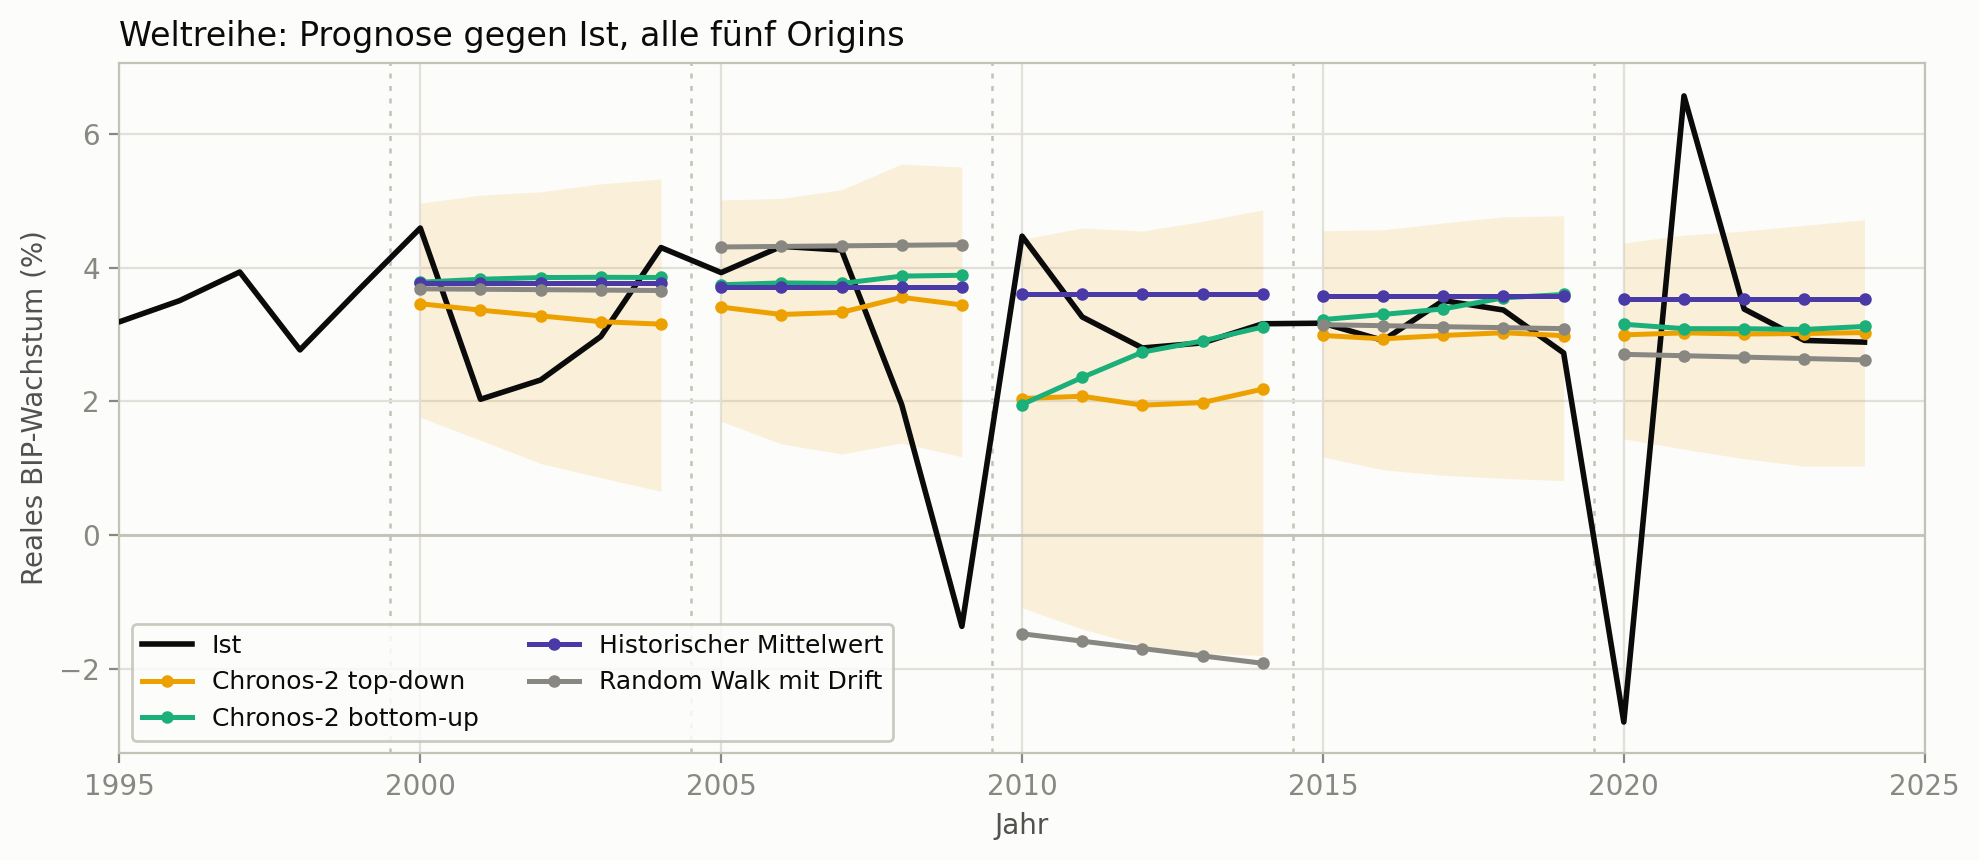

In [64]:
fig, ax = plt.subplots(figsize=(10, 4.4))

ax.plot(world_panel["year"], world_panel[TARGET],
        color=plotting.MODEL_COLORS["actual"], linewidth=2.0, label="Ist", zorder=3)

_style = {"chronos2_world": (plotting.MODEL_COLORS["chronos2"], "Chronos-2 top-down"),
          "chronos2_bottom_up": (plotting.SERIES_COLORS[1], "Chronos-2 bottom-up"),
          "mean_world": (plotting.SERIES_COLORS[4], "Historischer Mittelwert"),
          "rw_drift_world": (plotting.MUTED, "Random Walk mit Drift")}

for model, (color, label) in _style.items():
    d = preds_world_all[preds_world_all["model"] == model]
    for i, (origin, g) in enumerate(d.groupby("origin_year")):
        g = g.sort_values("year")
        ax.plot(g["year"], g["y_pred"], color=color, marker="o", markersize=3.5,
                linewidth=1.8, label=label if i == 0 else None, zorder=4)
        if model == "chronos2_world" and g[["q10", "q90"]].notna().all(axis=None):
            ax.fill_between(g["year"], g["q10"], g["q90"], color=color,
                            alpha=0.13, linewidth=0, zorder=1)

for origin in ORIGINS:
    ax.axvline(origin + 0.5, color=plotting.BASELINE, linewidth=0.9,
               linestyle=(0, (2, 3)), zorder=0)

ax.axhline(0, color=plotting.BASELINE, linewidth=1)
ax.set_xlim(1995, 2025)
ax.set_xlabel("Jahr")
ax.set_ylabel("Reales BIP-Wachstum (%)")
ax.set_title("Weltreihe: Prognose gegen Ist, alle fünf Origins",
             loc="left", color=plotting.INK)
plotting.add_legend(ax, loc="lower left", ncol=2)
fig.tight_layout()

### 6.6 Land gegen Welt, der eigentliche Vergleich

Der Vergleich muss auf einer gemeinsamen Skala stattfinden. Zwei Grössen werden
gegenübergestellt:

* **Absoluter Fehler (MAE, RMSE).** Direkt in Prozentpunkten interpretierbar und zwischen
  Land und Welt vergleichbar. Hier sollte sich die Dämpfung der idiosynkratischen Schocks
  zeigen.
* **Relative Güte (MASE).** Jeweils an der naiven Prognose *derselben* Reihe skaliert. Weil
  das Aggregat glatt ist, ist die naive Prognose dort stark. MASE misst also, wie viel über
  einen bereits guten Bezugspunkt hinaus gelernt wird, und ist zwischen den Ebenen nicht
  ohne Weiteres vergleichbar.

Zusätzlich wird der Länderfehler BIP-gewichtet gemittelt. Das ist der faire Bezugspunkt:
Ein Fehler in den USA wiegt für die Weltprognose schwerer als einer in Tuvalu.

In [65]:
# Absoluter Fehler auf beiden Ebenen, plus BIP-gewichteter Länderfehler
_c = preds_chronos2.dropna(subset=["y_true", "y_pred"]).copy()
_c["abs_error"] = (_c["y_true"] - _c["y_pred"]).abs()
_w = gdp_levels.stack().rename("gdp_level").reset_index()
_c = _c.merge(_w.rename(columns={"year": "origin_year"}),
              on=["country", "origin_year"], how="left")
_weighted_mae = float(np.average(_c["abs_error"].dropna(),
                                 weights=_c.loc[_c["abs_error"].notna(), "gdp_level"]))

_world_row = world_comparison.set_index("model").loc["chronos2_world"]
_bu_row = world_comparison.set_index("model").loc["chronos2_bottom_up"]

levels_table = pd.DataFrame([
    {"Ebene": "Einzelne Länder (ungewichtet)",
     "MAE": evaluation.mae(preds_chronos2["y_true"], preds_chronos2["y_pred"]),
     "RMSE": evaluation.rmse(preds_chronos2["y_true"], preds_chronos2["y_pred"]),
     "MASE": comparison.set_index("model").loc["chronos2", "MASE"],
     "n": len(preds_chronos2)},
    {"Ebene": "Einzelne Länder (BIP-gewichtet)",
     "MAE": _weighted_mae, "RMSE": np.nan, "MASE": np.nan, "n": len(_c)},
    {"Ebene": "Weltreihe (top-down)",
     "MAE": _world_row["MAE"], "RMSE": _world_row["RMSE"],
     "MASE": _world_row["MASE"], "n": len(preds_world)},
    {"Ebene": "Weltreihe (bottom-up)",
     "MAE": _bu_row["MAE"], "RMSE": _bu_row["RMSE"],
     "MASE": _bu_row["MASE"], "n": len(preds_world_bu)},
]).set_index("Ebene")
display(levels_table.round(3))

_country_mae = evaluation.mae(preds_chronos2["y_true"], preds_chronos2["y_pred"])
print(f"Der absolute Prognosefehler sinkt von {_country_mae:.2f} pp auf Länderebene "
      f"auf {_world_row['MAE']:.2f} pp auf Weltebene,")
print(f"also um den Faktor {_country_mae / _world_row['MAE']:.1f}.")
print(f"\nMASE steigt dagegen von {comparison.set_index('model').loc['chronos2', 'MASE']:.2f} "
      f"auf {_world_row['MASE']:.2f}: Auf der glatten Weltreihe ist die naive")
print("Prognose ein deutlich stärkerer Bezugspunkt als auf einer einzelnen Länderreihe.")

,MAE,RMSE,MASE,n
Ebene,,,,
Einzelne Länder (ungewichtet),3.089,5.447,0.848,2900
Einzelne Länder (BIP-gewichtet),2.016,NaN,NaN,2900
Weltreihe (top-down),1.252,1.894,1.053,25
Weltreihe (bottom-up),1.167,1.948,0.983,25


Der absolute Prognosefehler sinkt von 3.09 pp auf Länderebene auf 1.25 pp auf Weltebene,
also um den Faktor 2.5.

MASE steigt dagegen von 0.85 auf 1.05: Auf der glatten Weltreihe ist die naive
Prognose ein deutlich stärkerer Bezugspunkt als auf einer einzelnen Länderreihe.


### 6.7 Zwischenfazit zur Weltebene

Fünf Befunde, in der Reihenfolge ihrer Belastbarkeit.

1. **Das Aggregat ist absolut deutlich besser prognostizierbar.** Der mittlere absolute
   Fehler fällt von rund 3,1 Prozentpunkten auf Länderebene auf rund 1,2 auf Weltebene, also
   etwa um den Faktor 2,5. Das ist genau der Faktor, um den die Aggregation auch die
   Schwankung selbst dämpft (Standardabweichung 4,3 gegenüber 1,7 Prozentpunkten). Die
   eingangs zitierte Motivation bestätigt sich in diesem Punkt klar.
2. **Gegenüber dem historischen Mittelwert bleibt jedoch kein Vorsprung.** Das ist der
   zentrale Vorbehalt dieses Abschnitts. Die Klimatologie-Baseline erreicht einen MAE von
   1,19 und liegt damit **vor** der direkten Top-down-Prognose mit 1,25. Beim RMSE sind
   beide praktisch gleichauf, 1,90 gegenüber 1,89. Nur die bottom-up aggregierte Variante
   ist mit 1,17 minimal besser. Aufgeschlüsselt nach Origin gewinnt mal die eine, mal die
   andere Seite, und ausgerechnet im Krisenfold ab 2009 ist der schlichte Mittelwert mit
   0,64 klar am besten. Chronos-2 reproduziert auf dieser Reihe also im Wesentlichen den
   langfristigen Durchschnitt, ohne darüber hinaus verwertbare Struktur zu finden.
3. **Der Random Walk mit Drift ist auf dieser Reihe die falsche Messlatte.** Er scheitert
   mit einem MAE von 2,03 deutlich, aber fast ausschließlich in einem einzigen Fold: Ab
   2009 schreibt er den Einbruch der Finanzkrise linear fort und kommt auf 5,01. Gegen ihn
   sieht jedes Verfahren gut aus. Ein Skill-Nachweis, der nur auf diesem Vergleich beruht,
   wäre daher wertlos. Genau deshalb steht die Klimatologie daneben.
4. **MASE ist zwischen Länder- und Weltebene nicht vergleichbar.** Auf der Weltreihe wird an
   deren eigener naiver Prognose skaliert, und die ist auf einer glatten Reihe stark. Dass
   MASE von 0,85 auf 1,05 steigt, heißt deshalb nicht, dass das Modell auf der Weltebene
   schlechter arbeitet, sondern dass der Bezugspunkt dort härter ist. Für den Ebenenvergleich
   taugen nur MAE und RMSE in Prozentpunkten.
5. **Bottom-up, Länderkontext und Kovariaten ändern wenig.** Bottom-up liegt beim MAE vorn,
   der Unterschied ist mit p ≈ 0,46 gepoolt und p ≈ 0,53 geclustert aber weit von
   Signifikanz entfernt. Der Länderkontext über `cross_learning` verschiebt die Prognose um
   rund 0,11 Prozentpunkte und verschlechtert den MAE leicht, die Hypothese aus Abschnitt 6.3
   bestätigt sich also nicht. Die Kovariaten helfen auf der Weltreihe umgekehrt zur
   Länderebene minimal (1,25 gegenüber 1,29 ohne), was bei 25 Prognosepunkten ebenfalls
   nicht belastbar ist.

Wie wenig belastbar die Rangfolge insgesamt ist, zeigt der Blick auf die einzelnen Folds am
deutlichsten: **Vier verschiedene Verfahren gewinnen die fünf Folds.** Selbst der Random Walk
mit Drift, über alle Folds mit Abstand das schlechteste Verfahren, ist im ruhigen Fenster
2015 bis 2019 das beste von allen. Eine Rangfolge über fünf Origins suggeriert eine
Stabilität, die hier nicht vorhanden ist.

Bleibt als Gesamtbild: Die Aggregation senkt den absoluten Fehler erheblich, und in diesem
Sinn ist die Weltebene tatsächlich die sinnvollere Prognoseebene. Einen Beleg dafür, dass
das Foundation Model auf dem Aggregat mehr kann als den historischen Durchschnitt
fortzuschreiben, liefert dieser Backtest jedoch nicht.

## 7 Diskussion, Grenzen und Ausblick

**Einordnung.** Chronos-2 ist der einzige Beitrag im Vergleich, der ohne jede Anpassung an
die Daten auskommt. Er ist damit die härteste Probe auf die Frage, wie viel ein
universelles Foundation Model bei einer niederfrequenten, ökonomischen Aufgabe leistet.
Der aussagekräftige Bezugspunkt ist nicht der absolute Fehler, sondern der Abstand zur
Klimatologie und zu den trainierten Modellen aus den Notebooks 02 und 03. Gegen den Random
Walk mit Drift zu gewinnen genügt nicht, weil dieser für eine mittelwertrückkehrende
Zielgrösse die falsche Modellklasse ist und entsprechend schwach abschneidet. Gemessen an
der Klimatologie bleibt auf Länderebene ein Vorsprung von rund drei Prozent beim MAE,
während beim RMSE beide praktisch gleichauf liegen.

**Aggregatebene.** Der in Abschnitt 6 ergänzte Weltvergleich stützt die Ausgangsthese nur
zur Hälfte. Absolut sinkt der Prognosefehler durch die Aggregation etwa um den Faktor 2,5,
weil sich länderspezifische Schocks weitgehend herausmitteln. Gegen den angemessenen
Bezugspunkt gewinnt man dadurch aber nichts: Der schlichte historische Mittelwert der
Weltreihe erreicht einen kleineren MAE als die direkte Chronos-2-Prognose und ist beim RMSE
gleichauf. Wer aus der Literatur ableitet, Prognosen seien nur auf dem Aggregat sinnvoll,
sollte deshalb präzisieren, woran gemessen wird. Für eine Anwendung, die einen kleinen
absoluten Fehler in Prozentpunkten braucht, ist die Weltebene klar die richtige. Für die
Frage, ob ein Modell überhaupt ausbeutbare Struktur findet, ist sie der härtere Prüfstein,
nicht der leichtere, denn dort ist schon der Durchschnitt eine starke Prognose.

**Grenzen.** Erstens ist jährliches BIP-Wachstum mit rund 35 bis 64 Beobachtungen je Land
kurz und niederfrequent und liegt außerhalb des typischen Trainingsregimes von Chronos-2.
Zweitens ist ein Strukturbruch wie der COVID-Einbruch 2020 aus der Vergangenheit heraus
grundsätzlich nicht prognostizierbar. Der finale Fold ist entsprechend zu lesen. Damit
verbunden ist eine **bedingte Fehlkalibrierung**: Die über alle Folds gemittelte
80-Prozent-Abdeckung liegt zwar nahe am Sollwert, im COVID-Fold bricht sie jedoch deutlich
ein (siehe Abschnitt 5.6), weil die Prognoseintervalle den plötzlichen Einbruch nicht
umfassen. Ein global gut kalibriertes Intervall ist also nicht automatisch unter
Strukturbrüchen verlässlich. Drittens gelten die known-future-Demografietreiber im Backtest
als bekannt, indem ihre tatsächlich realisierten Werte übergeben werden, ganz wie beim
Temporal Fusion Transformer. Das ist eine bewusste, für alle Modelle gleiche Konvention und
keine unfaire Bevorzugung. Viertens beruht der gesamte Weltvergleich auf nur 25
Prognosepunkten aus fünf Origins. Rangfolgen zwischen eng beieinanderliegenden Varianten,
etwa Bottom-up gegenüber Top-down, sind damit nicht belastbar. Fünftens beruht der gesamte
Backtest auf dem heutigen, mehrfach revidierten Datenstand der Weltbank. Wer im Jahr 2000
prognostizierte, verfügte über andere Zahlen für die Vorjahre, als sie heute in der Datenbank
stehen. Dieser Datenvintage-Effekt trifft alle verglichenen Modelle gleichermaßen, der
Vergleich untereinander bleibt also fair, das absolute Güteniveau ist dadurch aber
tendenziell zu optimistisch. Ein streng realistischer Backtest bräuchte Echtzeitdaten, also
den jeweils zum Prognosezeitpunkt veröffentlichten Stand.

**Ausblick.** Denkbar wären ein Fine-Tuning von Chronos-2 auf dem Panel als Mittelweg
zwischen Zero-Shot und vollständig trainierten Modellen, eine gezielte Auswahl oder
Transformation der Kovariaten sowie eine explizite Modellierung der Krisenjahre. Der
naheliegendste nächste Schritt ist aber ein externer Bezugspunkt: Der World Economic Outlook
des Internationalen Währungsfonds veröffentlicht seit Jahrzehnten Fünfjahresprojektionen für
das Weltwachstum, die Archive sind öffentlich. Für eine betriebswirtschaftliche Fragestellung
ist nicht entscheidend, ob ein Modell einen Random Walk schlägt, sondern ob es mit den
Prognosen mithält, an denen sich Unternehmen tatsächlich orientieren. Der faire
Zero-Shot-Vergleich in diesem Notebook bildet dafür die Grundlage.

## 8 Schnittstelle zu Notebook 05

Dieses Notebook liefert Notebook 05 zwei Ebenen.

**Länderebene.** `data/results/preds_chronos2.csv` im Schema `config.RESULTS_COLUMNS`,
geladen über `evaluation.load_all_predictions()` gemeinsam mit den übrigen Modellen.

**Weltebene.** `data/results/world/preds_chronos2_world.csv` und
`preds_chronos2_world_ctx.csv`, geladen über `evaluation.load_all_world_predictions()`.
Der eigene Unterordner verhindert, dass die 25-zeiligen Weltprognosen in den
Ländervergleich geraten.

Für den Weltvergleich über **alle** Modelle braucht Notebook 05 keine weiteren Dateien.
Die Bausteine liegen in `src`:

```python
from src import data_utils, evaluation

panel = data_utils.load_panel()
world_panel, gdp_levels = data_utils.build_world_panel(panel)

# Bottom-up-Weltprognose für JEDES Modell mit Länderprognosen
country_preds = evaluation.load_all_predictions()
world_bottom_up = evaluation.aggregate_bottom_up(
    country_preds, gdp_levels, world_panel)      # -> <modell>_bottom_up

# Direkte Top-down-Weltprognosen, soweit ein Notebook sie gespeichert hat
world_top_down = evaluation.load_all_world_predictions()

# Gemeinsam auswerten, MASE wird an der WELTREIHE skaliert
import pandas as pd
evaluation.summarize(pd.concat([world_bottom_up, world_top_down],
                               ignore_index=True), world_panel)
```

Zwei Punkte, die dabei zu beachten sind:

* **MASE ist zwischen den Ebenen nicht vergleichbar.** Auf der Weltreihe wird an deren
  eigener naiver Prognose skaliert, und die ist auf einer glatten Reihe deutlich stärker
  (Abschnitte 6.6 und 6.7). Für den Ebenenvergleich taugen MAE und RMSE in Prozentpunkten.
* **Bottom-up hat keine Quantile.** `aggregate_bottom_up()` lässt `q10`/`q90` leer, weil
  Quantile nicht additiv sind. Kalibrierungsmaße sind dort also nur für die direkten
  Top-down-Prognosen definiert.

Die folgende Zelle prüft beide Exporte.

In [66]:
# --- Länderebene ---------------------------------------------------------
out_path = config.RESULTS_DIR / "preds_chronos2.csv"
assert out_path.exists(), "preds_chronos2.csv fehlt, Abschnitt 4 muss zuerst laufen."
check = pd.read_csv(out_path)
assert list(check.columns) == config.RESULTS_COLUMNS
assert (check["model"] == "chronos2").all()
print(f"Länderebene geprüft: {config.rel(out_path)}")
print(f"  {len(check):,} Zeilen, Origins "
      f"{sorted(int(o) for o in check['origin_year'].unique())}, "
      f"{check['country'].nunique()} Länder")

# --- Weltebene ------------------------------------------------------------
world_check = evaluation.load_all_world_predictions()
assert list(world_check.columns) == config.RESULTS_COLUMNS
assert (world_check["country"] == config.WORLD_ID).all()
print(f"\nWeltebene geprüft: {config.rel(config.WORLD_RESULTS_DIR)}")
for model, g in world_check.groupby("model"):
    print(f"  {model:20s} {len(g):3d} Prognosen, "
          f"{g['origin_year'].nunique()} Origins")

# Weltdateien dürfen NIE im Ordner der Länderprognosen landen, sonst zieht
# load_all_predictions() sie in den Ländervergleich.
_stray = [p.name for p in config.RESULTS_DIR.glob("preds_*.csv")
          if config.WORLD_ID in pd.read_csv(p, usecols=["country"])["country"].values]
assert not _stray, f"Weltprognosen im Länderordner gefunden: {_stray}"
print("\nOK: Keine Weltprognosen im Länderordner, Notebook 05 kann sauber trennen.")

# Gegenprobe: genau der Aufruf, den Notebook 05 für alle Modelle nutzen wird
_bu_all = evaluation.aggregate_bottom_up(
    evaluation.load_all_predictions(), gdp_levels, world_panel)
print(f"\nBottom-up aus allen Ländermodellen: "
      f"{sorted(_bu_all['model'].unique())}")
display(evaluation.summarize(
    pd.concat([_bu_all, world_check], ignore_index=True), world_panel).round(3))

Länderebene geprüft: data/results/preds_chronos2.csv
  2,900 Zeilen, Origins [1999, 2004, 2009, 2014, 2019], 116 Länder

Weltebene geprüft: data/results/world
  chronos2_world        25 Prognosen, 5 Origins
  chronos2_world_ctx    25 Prognosen, 5 Origins
  chronos2_world_uni    25 Prognosen, 5 Origins

OK: Keine Weltprognosen im Länderordner, Notebook 05 kann sauber trennen.

Bottom-up aus allen Ländermodellen: ['chronos2_bottom_up', 'rw_drift_bottom_up', 'tft_bottom_up']


,model,MASE,RMSE,MAE,pinball_q10,pinball_q90,coverage_80,n_forecasts
0,chronos2_bottom_up,0.983,1.948,1.167,NaN,NaN,NaN,25
1,chronos2_world,1.053,1.894,1.252,0.507,0.272,0.84,25
2,chronos2_world_ctx,1.070,1.947,1.272,0.508,0.301,0.84,25
3,chronos2_world_uni,1.081,1.968,1.286,0.504,0.317,0.84,25
4,tft_bottom_up,1.106,2.078,1.315,NaN,NaN,NaN,25
5,rw_drift_bottom_up,1.661,2.789,1.982,NaN,NaN,NaN,25
